# Master Notebook: All Models End-to-End

This notebook is fully self-contained. It embeds the environment wrappers, agents, training utilities, and plotting code from `src/` so you can run every model in one place.

What it does:
- Defines all models (Q-learning, SARSA, DQN, REINFORCE, SAC, PPO, Simple GA, CMA-ES, NEAT).
- Runs training for each configured experiment and seed, or reuses existing logs.
- Saves logs and produces comparison plots plus per-model learning curves.

Notes:
- PPO is disabled by default because it runs long. Toggle `SKIP_PPO` below if you want it.
- Some models require optional dependencies (PyTorch, stable-baselines3, neat-python, cma).
- If you already have logs in `outputs/logs`, set `USE_LOGS_ONLY=True` to skip training and plot immediately.
- Long runtimes: consider reducing `episodes` or limiting configs.


## GA-style report (automated plots)

This notebook embeds a `ga_report` utility that produces the comparison plots used in the GA report: final evaluation mean reward, success rate, and per-config learning curves.

Behavior:
- If `scripts/ga_report.py` exists, the notebook will import and use it (so you can maintain the script separately).
- If the script is missing, an embedded implementation (below) is available and will be used instead.

Use the following cells to (1) check for an external script, (2) load/define plotting functions, and (3) run the report generation to produce files under `outputs/figures`.

In [41]:
# Check for external scripts/ga_report.py and import it if present
from pathlib import Path
script_path = Path('scripts/ga_report.py')
external_ga = False
if script_path.exists():
    try:
        import importlib.util, sys
        spec = importlib.util.spec_from_file_location('ga_report_module', str(script_path))
        ga_mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(ga_mod)
        # expose plot_comparisons from external script
        plot_comparisons = getattr(ga_mod, 'plot_comparisons', None)
        external_ga = plot_comparisons is not None
        print('Loaded external scripts/ga_report.py')
    except Exception as e:
        print('Failed to load external ga_report.py:', e)
        external_ga = False
else:
    print('No external scripts/ga_report.py found; using embedded functions (next cell)')

No external scripts/ga_report.py found; using embedded functions (next cell)


In [42]:
# Embedded GA report functions (copied here so the notebook can run standalone)
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='talk')
except Exception:
    sns = None

def _load_summaries(logs_dir: Path):
    summaries = []
    episode_logs = []
    for p in sorted(Path(logs_dir).glob('*_summary.json')):
        try:
            s = json.loads(p.read_text())
            fallback = p.name.replace('_summary.json', '')
            summaries.append({
                'config_name': s.get('experiment_name', fallback),
                'seed': s.get('seed'),
                'agent': s.get('agent'),
                'reward_mean': s.get('reward_mean'),
                'reward_std': s.get('reward_std'),
                'success_rate': s.get('success_rate'),
                'eval_mean_reward_last': s.get('eval_mean_reward_last'),
            })
        except Exception:
            continue
    for p in sorted(Path(logs_dir).glob('*_episodes.csv')):
        try:
            df = pd.read_csv(p)
            name = p.name.replace('_episodes.csv', '')
            episode_logs.append((name, df))
        except Exception:
            continue
    return pd.DataFrame(summaries), episode_logs

def plot_comparisons_embedded(logs_dir: str | Path = 'outputs/logs', out_dir: str | Path = 'outputs/figures'):
    logs_dir = Path(logs_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    summaries, episode_logs = _load_summaries(logs_dir)
    if summaries.empty:
        print('No summaries found in', logs_dir)
        return

    agg = summaries.groupby('config_name', as_index=False).agg({'eval_mean_reward_last': 'mean', 'success_rate': 'mean', 'reward_mean': 'mean'})

    if 'eval_mean_reward_last' in agg.columns:
        plt.figure(figsize=(10, 4))
        if sns is not None:
            sns.barplot(data=agg, x='config_name', y='eval_mean_reward_last')
        else:
            plt.bar(agg['config_name'], agg['eval_mean_reward_last'])
        plt.xticks(rotation=45, ha='right')
        plt.title('Final evaluation mean reward by config')
        plt.tight_layout()
        path = out_dir / 'ga_comparison_eval_mean_reward.png'
        plt.savefig(path, dpi=180)
        plt.show()
        print('Saved', path)

    if 'success_rate' in agg.columns:
        plt.figure(figsize=(10, 4))
        if sns is not None:
            sns.barplot(data=agg, x='config_name', y='success_rate')
        else:
            plt.bar(agg['config_name'], agg['success_rate'])
        plt.xticks(rotation=45, ha='right')
        plt.title('Success rate by config')
        plt.tight_layout()
        path = out_dir / 'ga_comparison_success_rate.png'
        plt.savefig(path, dpi=180)
        plt.show()
        print('Saved', path)

    # per-model learning curves
    if episode_logs:
        grouped = {}
        for name, df in episode_logs:
            cfg = name
            grouped.setdefault(cfg, []).append(df)
        for cfg, dfs in grouped.items():
            plt.figure(figsize=(10, 4))
            for df in dfs:
                if 'episode' in df.columns and 'reward' in df.columns:
                    y = df['reward'].rolling(window=50, min_periods=1).mean()
                    plt.plot(df['episode'], y, alpha=0.7)
            plt.xlabel('Episode')
            plt.ylabel('Reward (rolling mean)')
            plt.title(f'Learning curve: {cfg}')
            plt.tight_layout()
            path = out_dir / f'ga_{cfg}_learning_curve.png'
            plt.savefig(path, dpi=180)
            plt.show()
            print('Saved', path)
    else:
        print('No per-episode logs found.')

# If external script wasn't loaded, make embedded function available as plot_comparisons
if not globals().get('plot_comparisons', None):
    plot_comparisons = plot_comparisons_embedded

## How to Use This Notebook

This notebook has three phases:
1. **Setup:** load dependencies and define environments + agents.
2. **Run or reuse:** either train models or reuse existing logs.
3. **Visualize:** generate per-model curves and cross-model comparisons.

Recommended workflow:
- Keep `USE_LOGS_ONLY=True` if you already have data in `outputs/logs`.
- Turn `SKIP_PPO=False` only if you want the PPO run and have time.
- For quick sanity checks, keep `RUN_FAST=True` and limit configs.

Outputs:
- Per-model curves saved to `outputs/figures/*_learning_curve.png`.
- Comparison plots saved to `outputs/figures/comparison_*.png`.

In [43]:
# Imports and dependency checks
import sys
import os
import json
import time
import math
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except Exception:
    SEABORN_AVAILABLE = False
    sns = None

try:
    import gymnasium as gym
    GYM_AVAILABLE = True
except Exception:
    GYM_AVAILABLE = False
    gym = None

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False
    torch = None
    nn = None
    optim = None

try:
    from stable_baselines3 import DQN, SAC, PPO
    SB3_AVAILABLE = True
except Exception:
    SB3_AVAILABLE = False
    DQN = SAC = PPO = None

try:
    import neat
    NEAT_AVAILABLE = True
except Exception:
    NEAT_AVAILABLE = False
    neat = None

try:
    import cma
    CMA_AVAILABLE = True
except Exception:
    CMA_AVAILABLE = False
    cma = None

try:
    import yaml
    YAML_AVAILABLE = True
except Exception:
    YAML_AVAILABLE = False
    yaml = None

PROJECT_ROOT = Path('..').resolve() if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
print('Project root:', PROJECT_ROOT)
print('Deps: gym=', GYM_AVAILABLE, 'torch=', TORCH_AVAILABLE, 'sb3=', SB3_AVAILABLE, 'neat=', NEAT_AVAILABLE, 'cma=', CMA_AVAILABLE)

Project root: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum
Deps: gym= True torch= True sb3= True neat= False cma= False


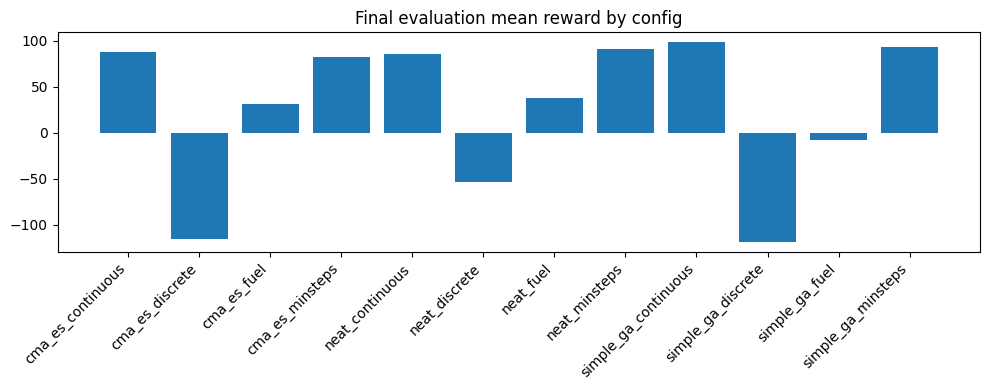

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_comparison_eval_mean_reward.png


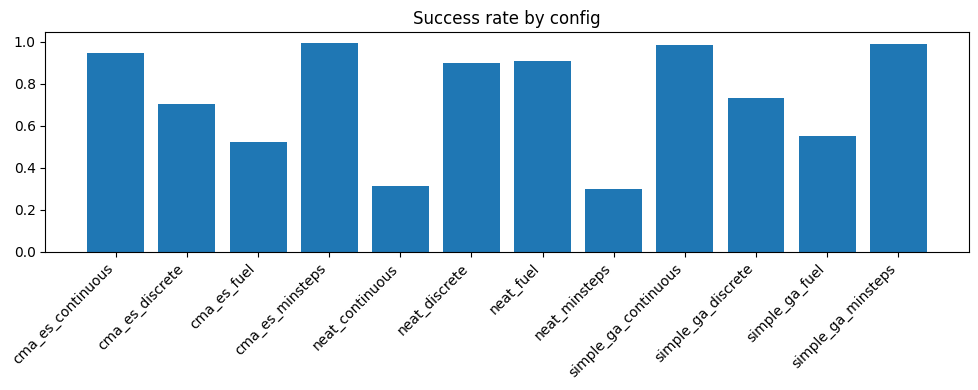

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_comparison_success_rate.png


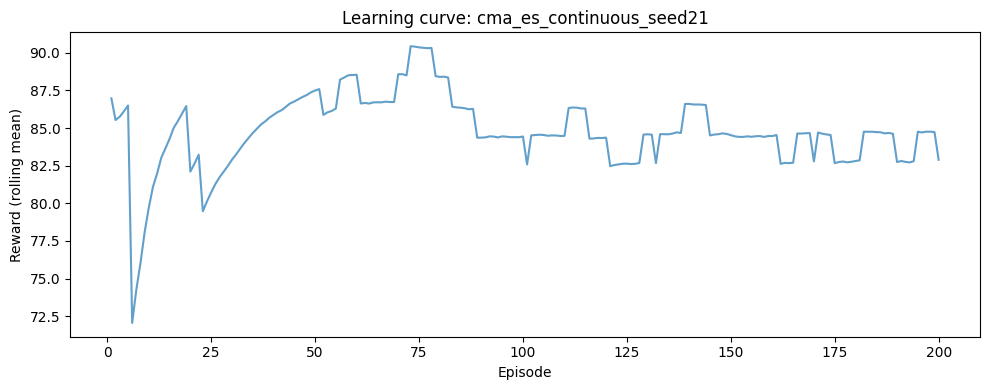

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_continuous_seed21_learning_curve.png


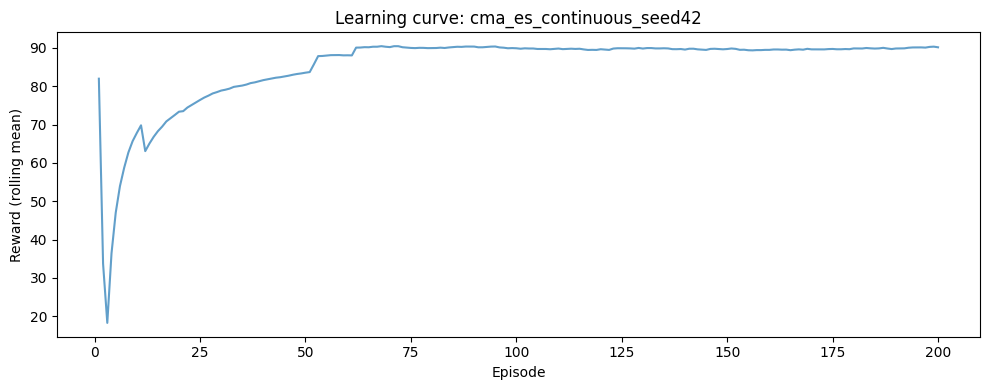

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_continuous_seed42_learning_curve.png


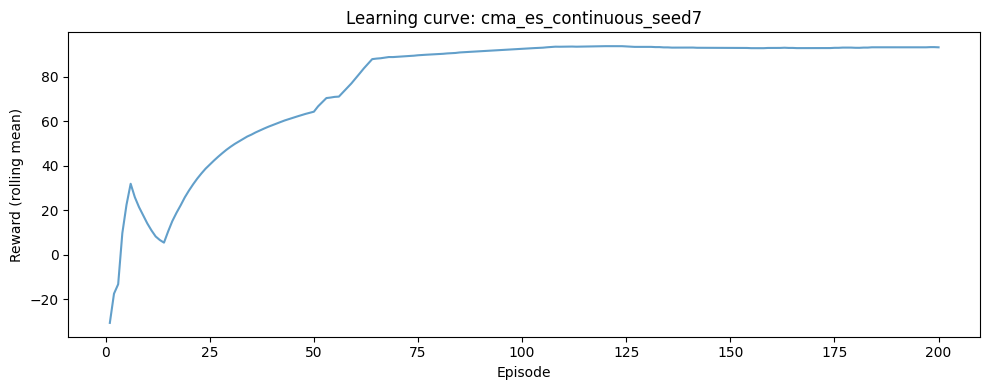

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_continuous_seed7_learning_curve.png


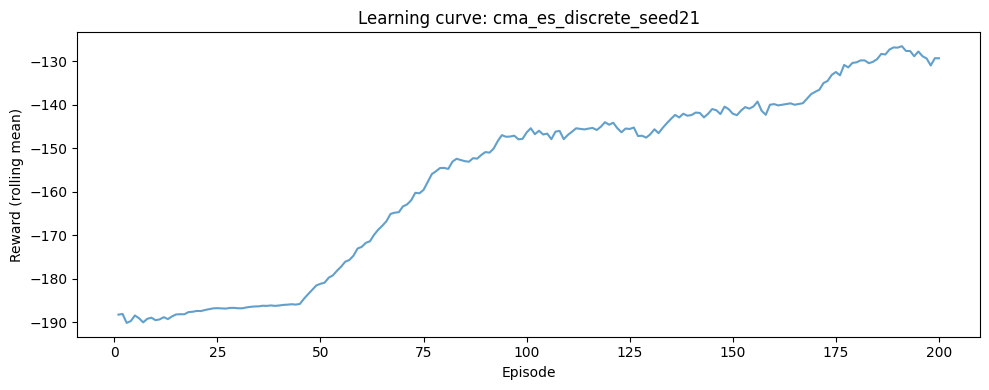

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_discrete_seed21_learning_curve.png


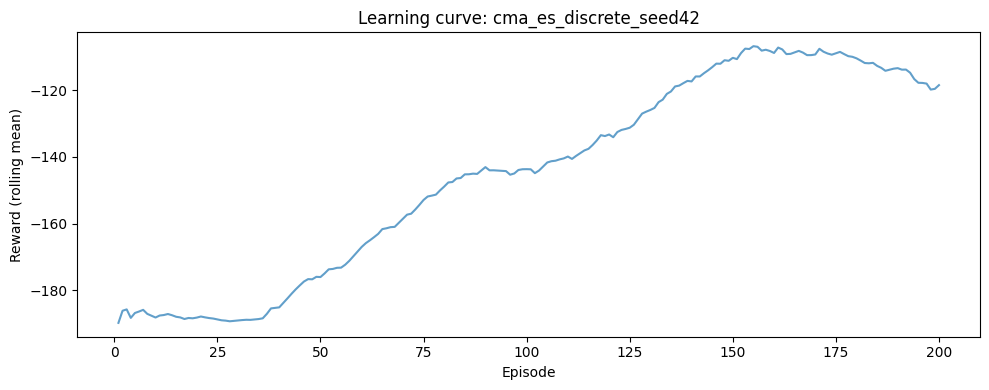

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_discrete_seed42_learning_curve.png


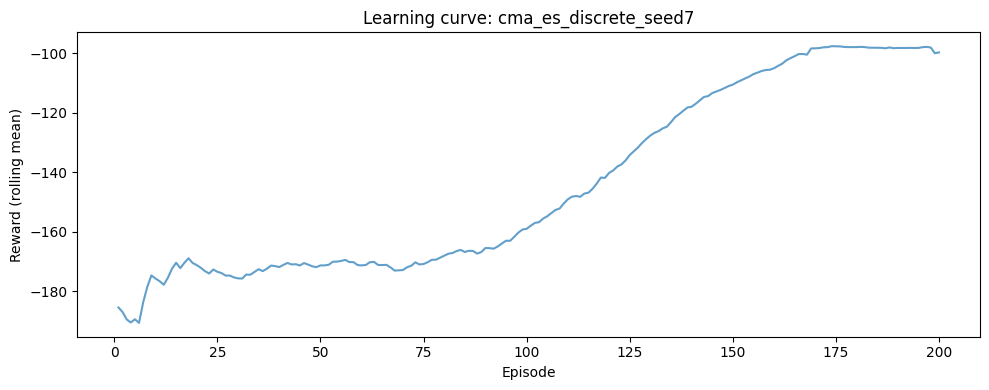

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_discrete_seed7_learning_curve.png


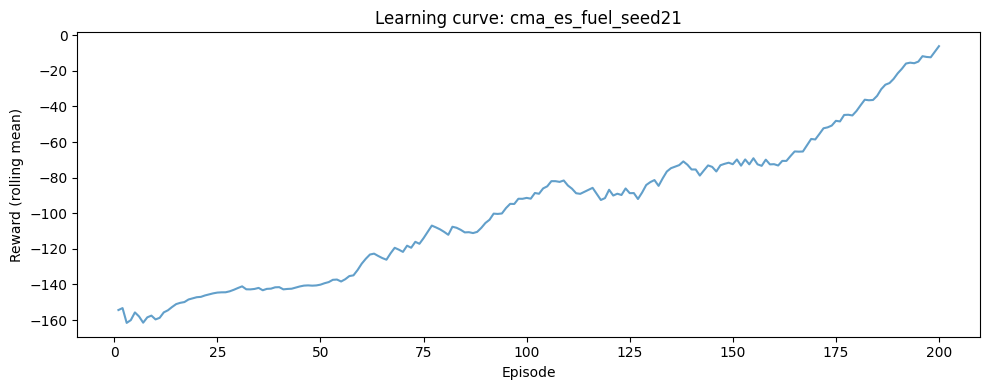

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_fuel_seed21_learning_curve.png


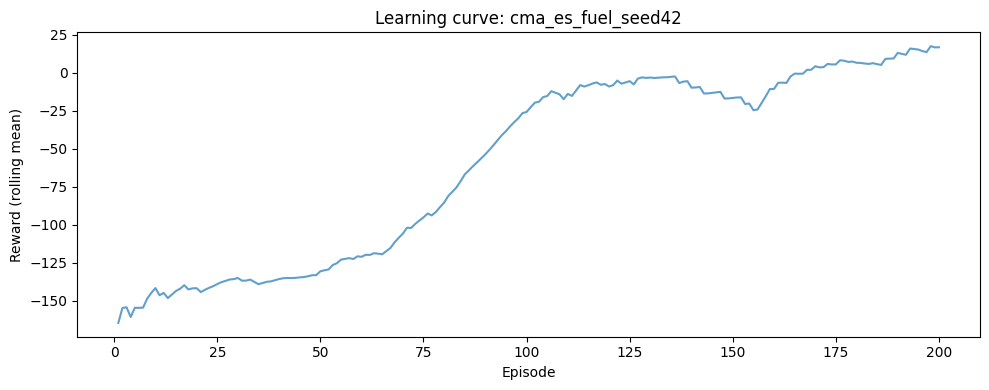

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_fuel_seed42_learning_curve.png


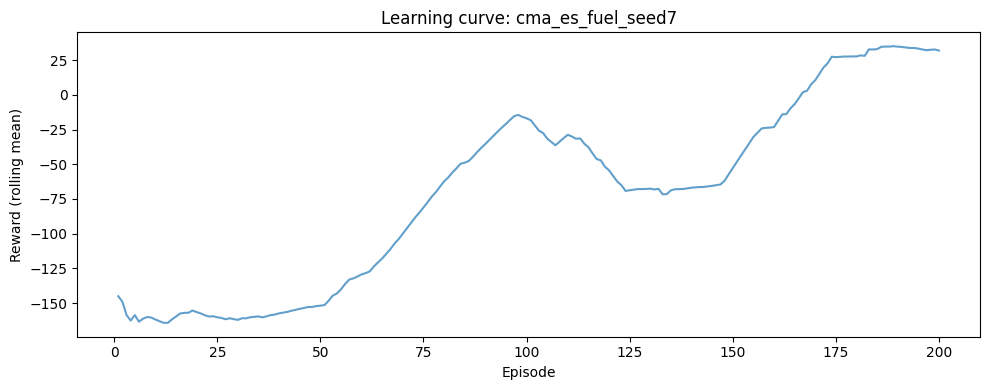

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_fuel_seed7_learning_curve.png


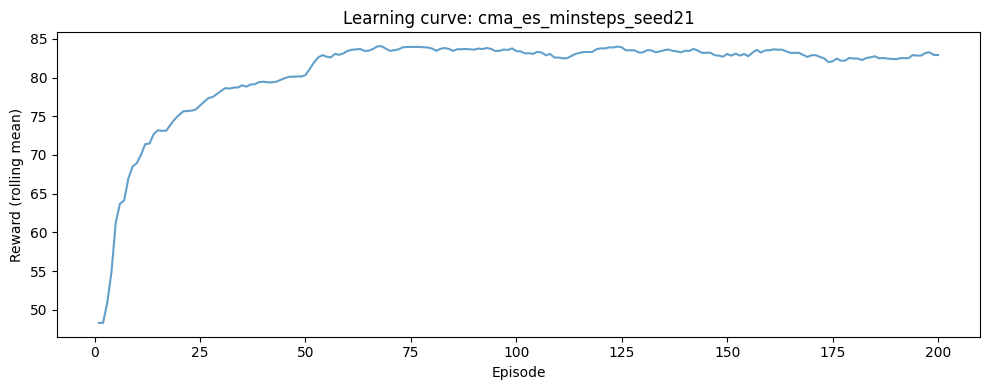

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_minsteps_seed21_learning_curve.png


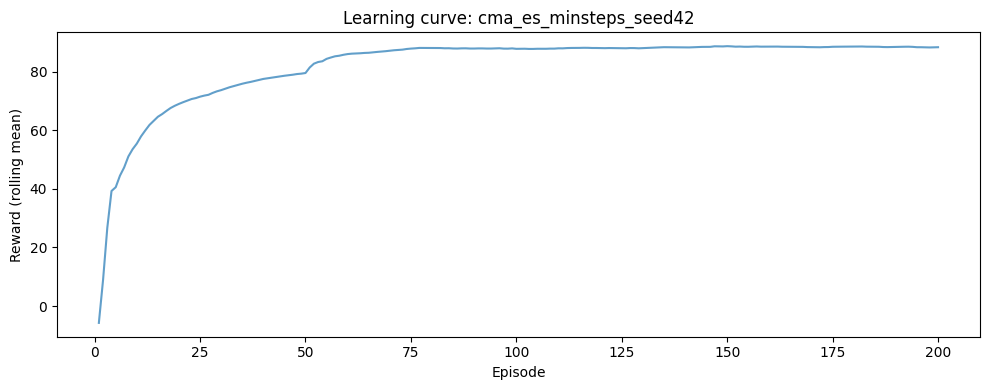

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_minsteps_seed42_learning_curve.png


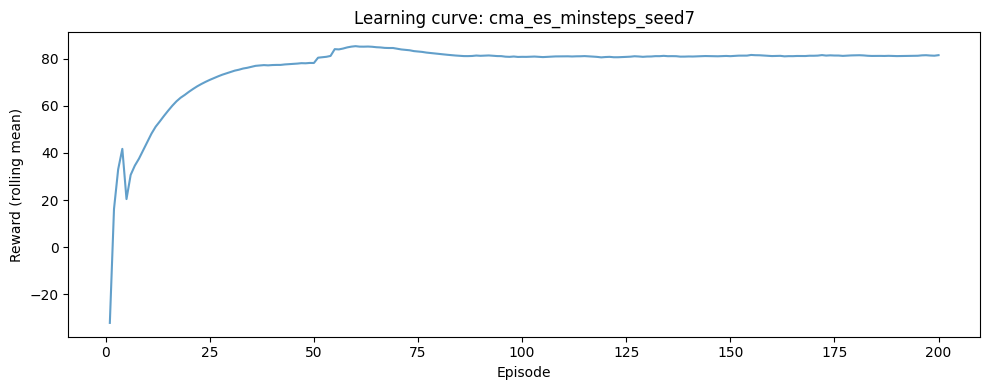

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_cma_es_minsteps_seed7_learning_curve.png


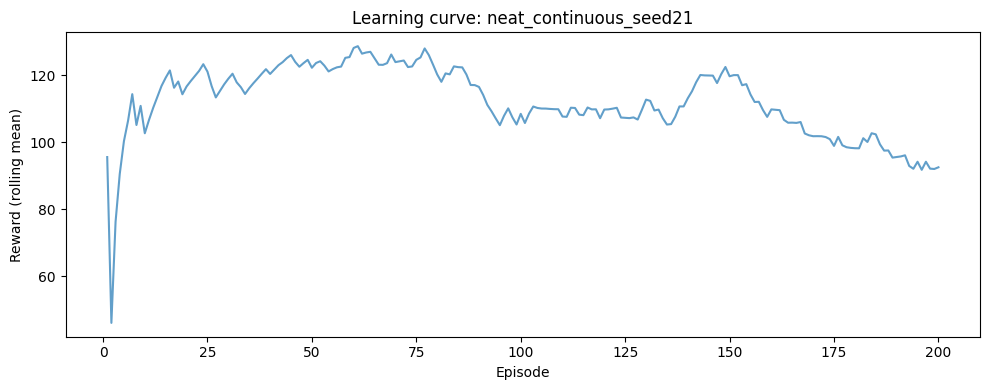

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_continuous_seed21_learning_curve.png


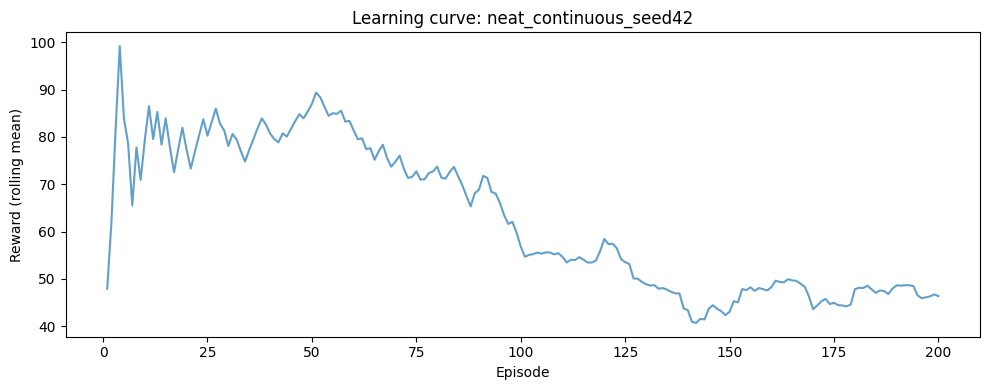

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_continuous_seed42_learning_curve.png


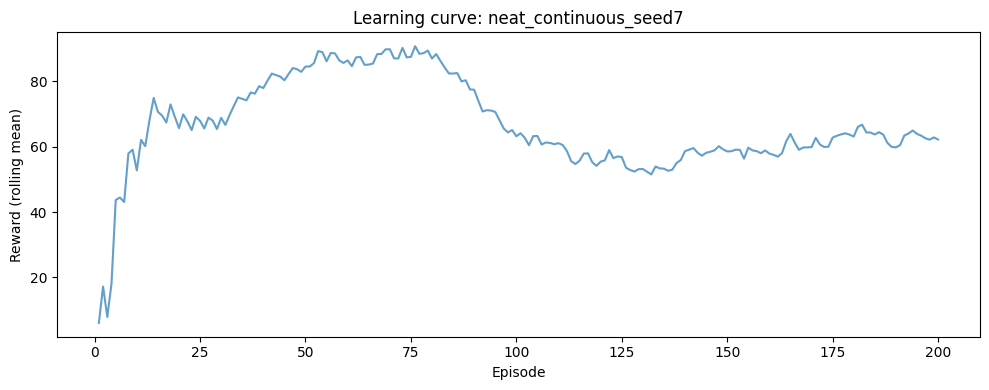

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_continuous_seed7_learning_curve.png


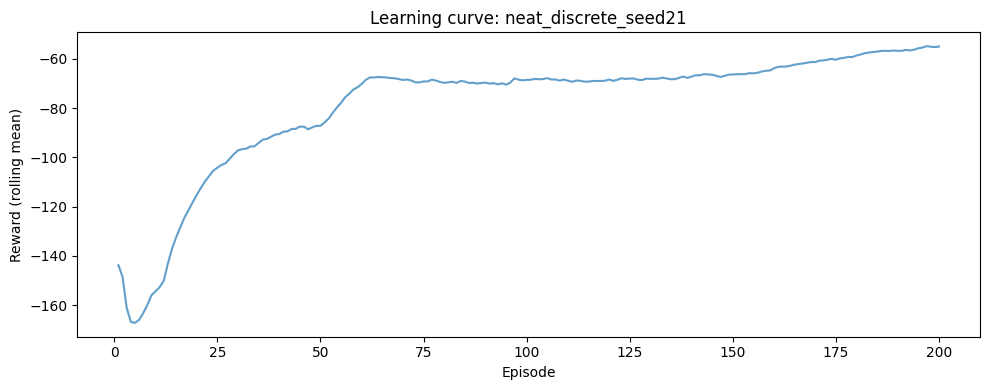

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_discrete_seed21_learning_curve.png


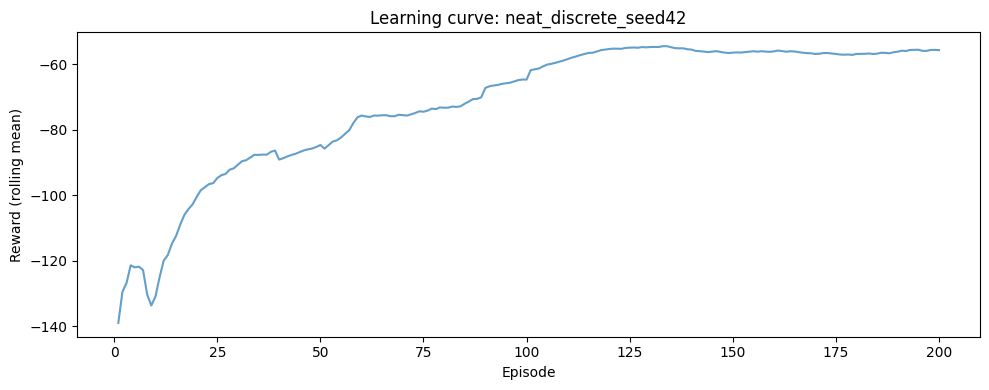

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_discrete_seed42_learning_curve.png


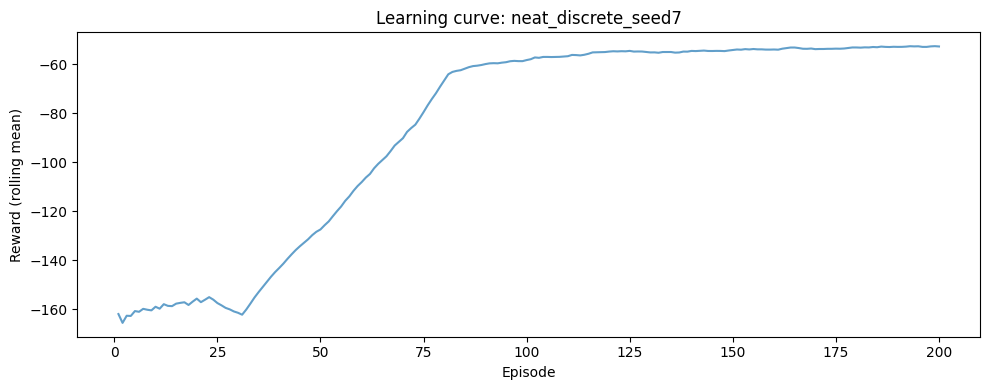

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_discrete_seed7_learning_curve.png


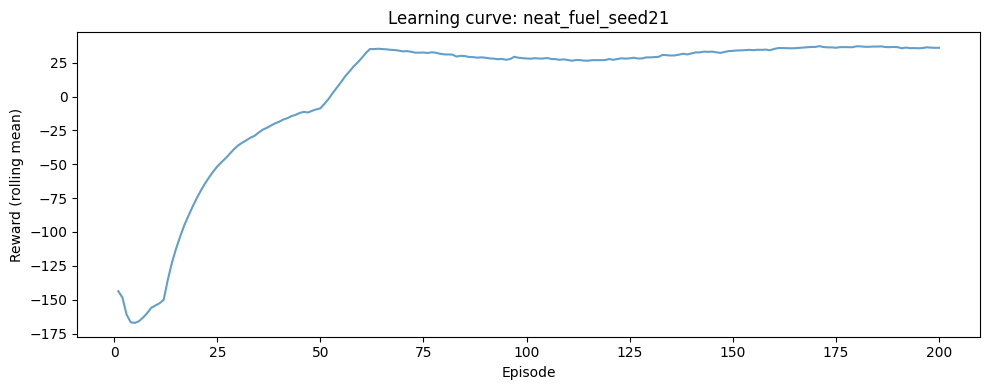

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_fuel_seed21_learning_curve.png


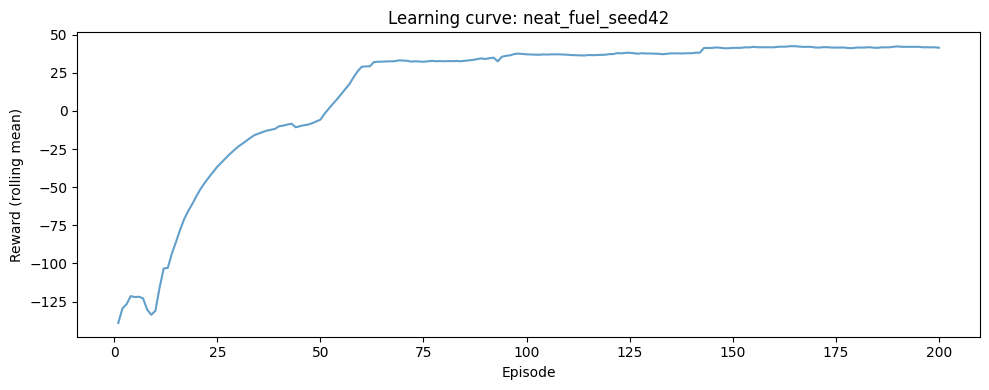

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_fuel_seed42_learning_curve.png


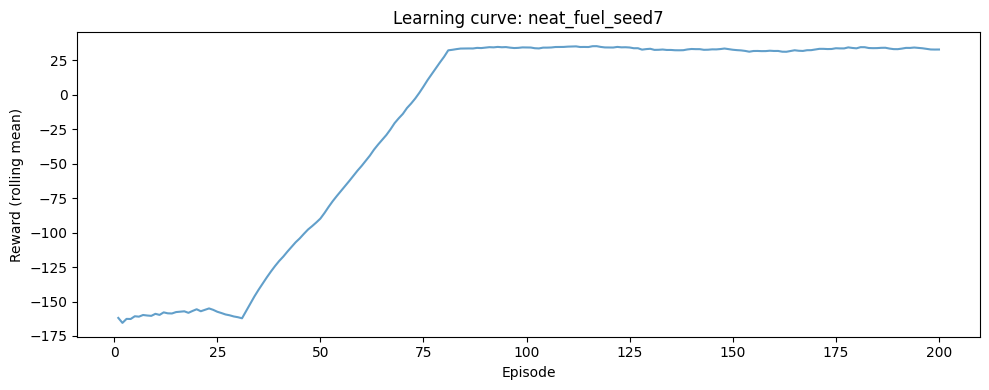

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_fuel_seed7_learning_curve.png


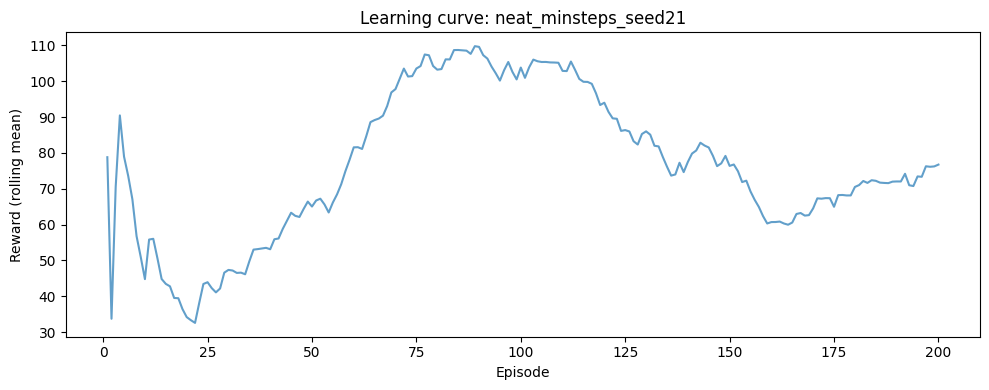

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_minsteps_seed21_learning_curve.png


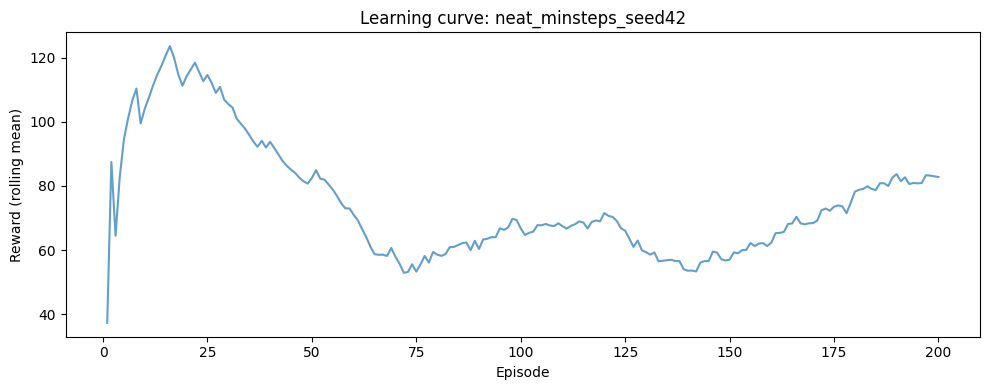

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_minsteps_seed42_learning_curve.png


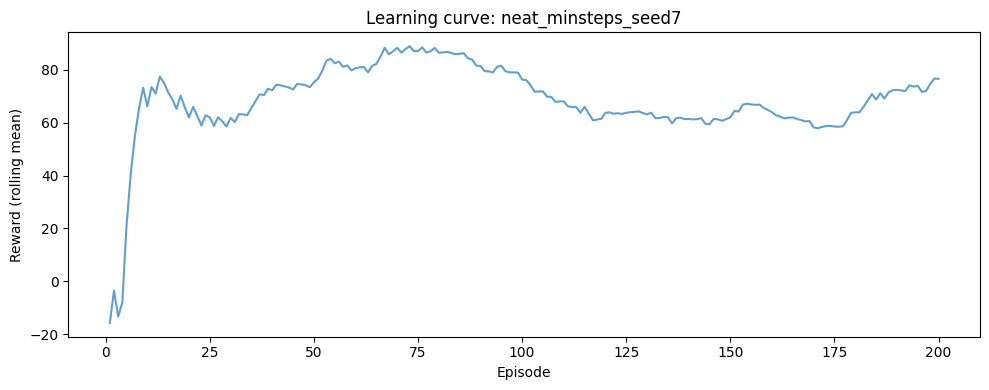

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_neat_minsteps_seed7_learning_curve.png


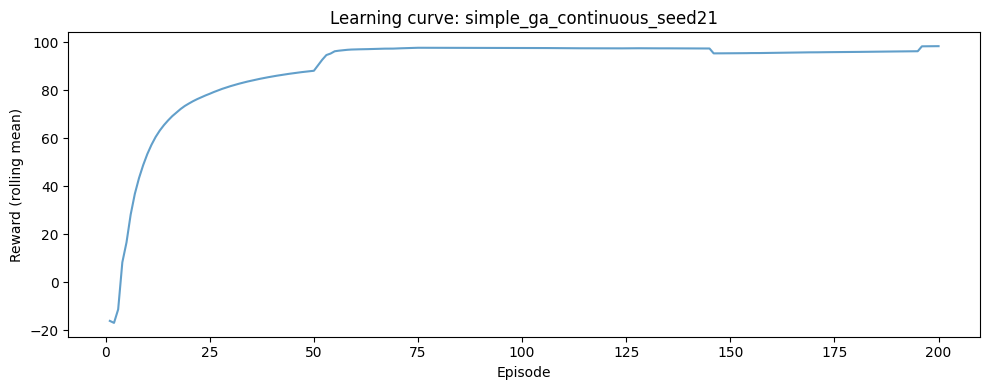

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_continuous_seed21_learning_curve.png


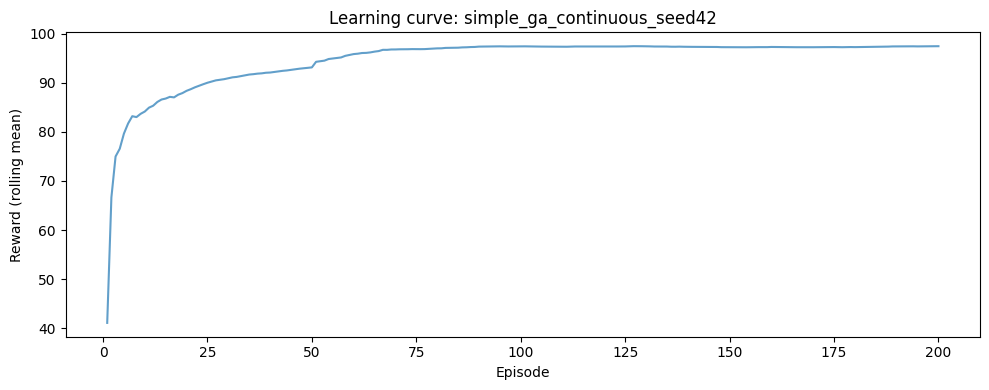

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_continuous_seed42_learning_curve.png


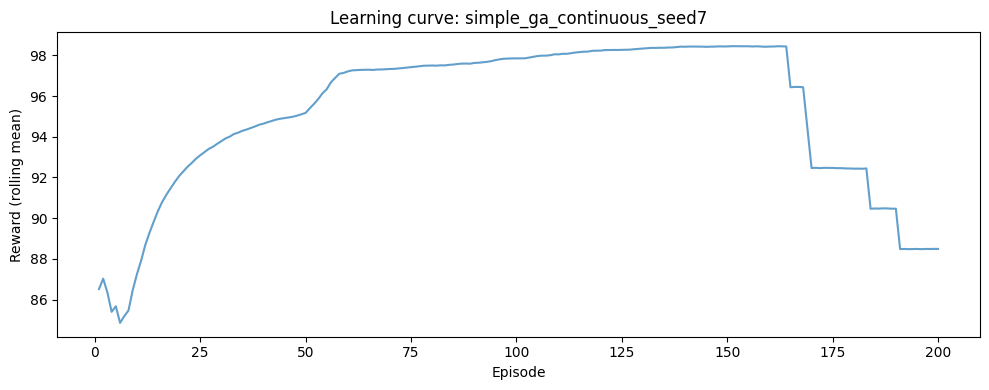

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_continuous_seed7_learning_curve.png


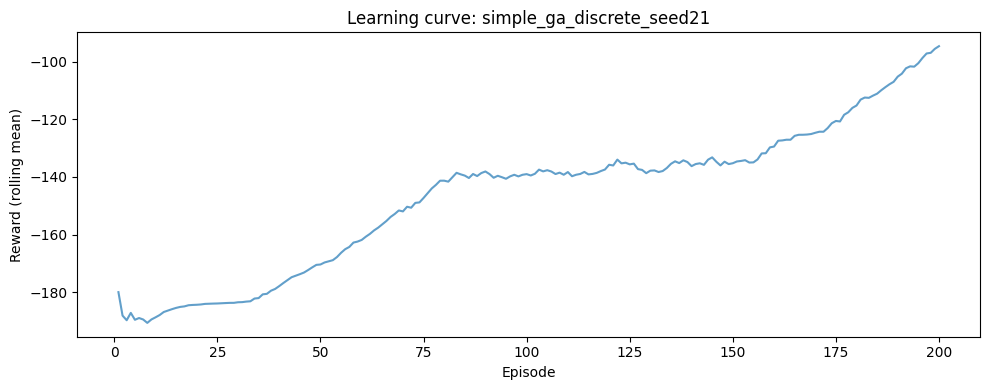

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_discrete_seed21_learning_curve.png


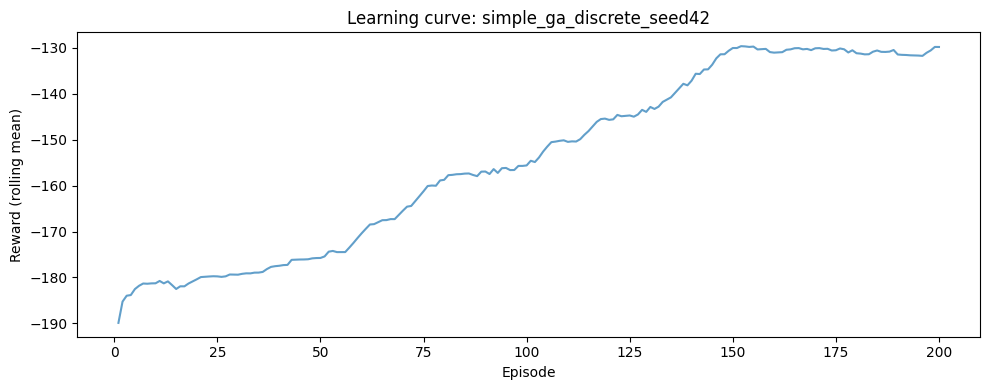

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_discrete_seed42_learning_curve.png


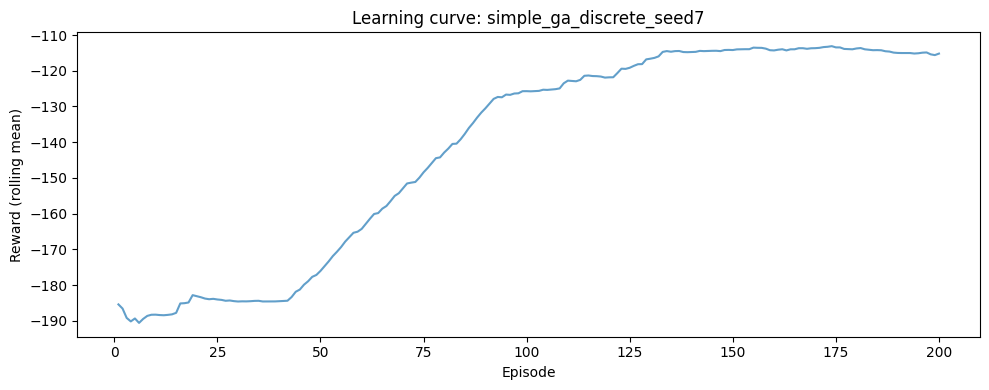

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_discrete_seed7_learning_curve.png


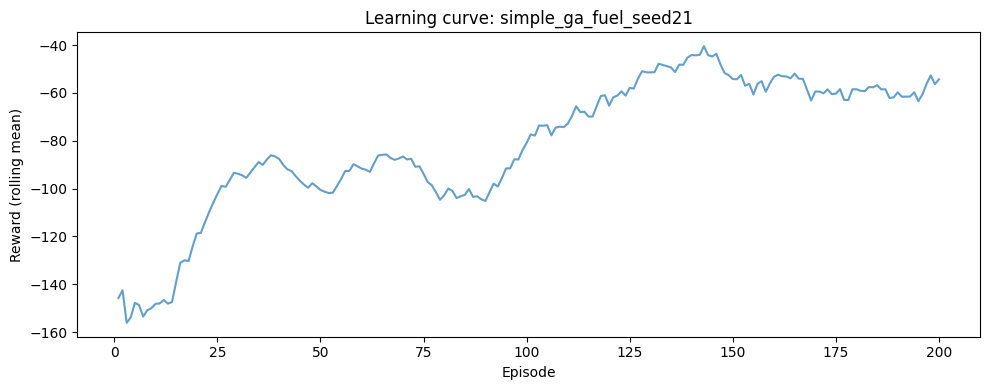

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_fuel_seed21_learning_curve.png


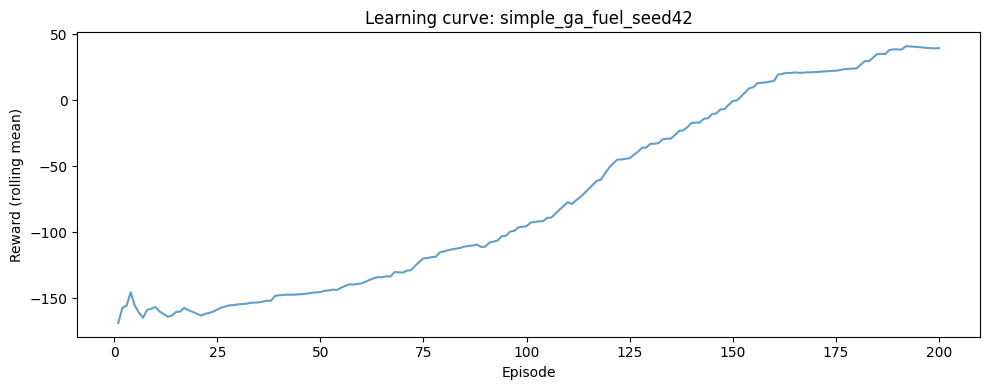

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_fuel_seed42_learning_curve.png


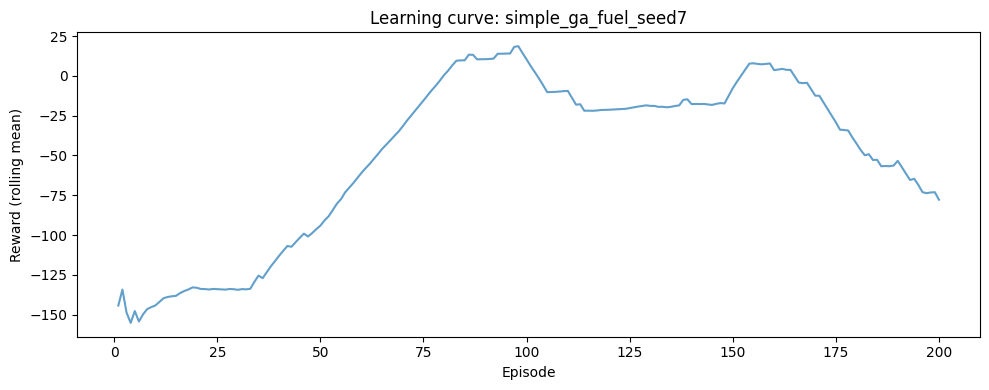

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_fuel_seed7_learning_curve.png


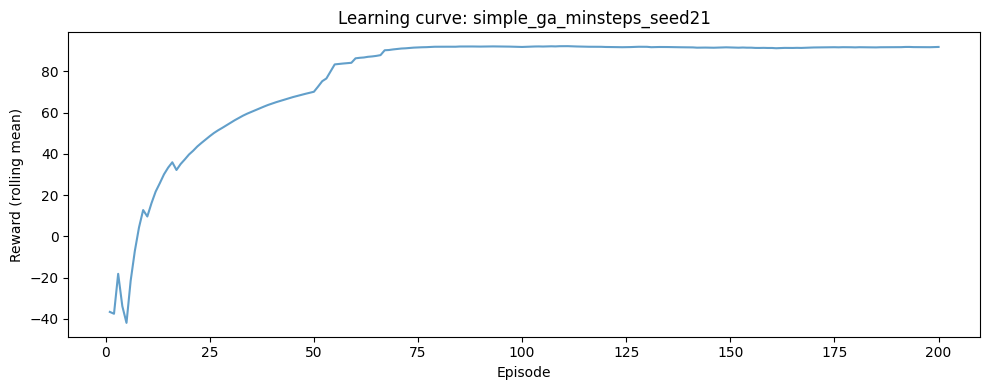

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_minsteps_seed21_learning_curve.png


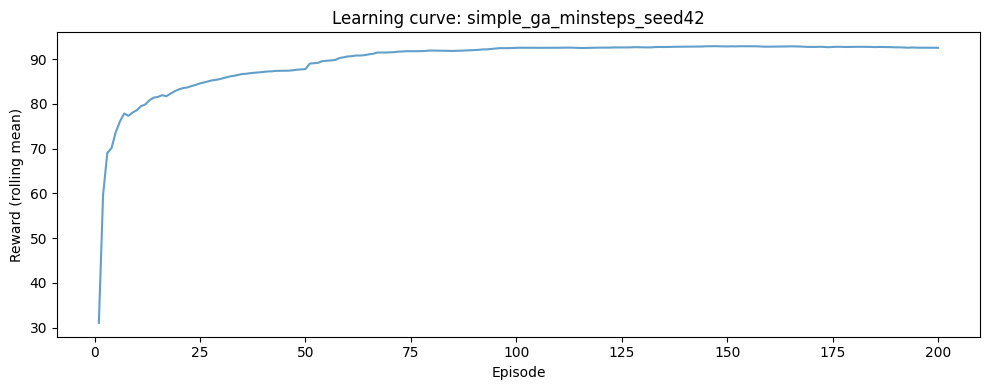

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_minsteps_seed42_learning_curve.png


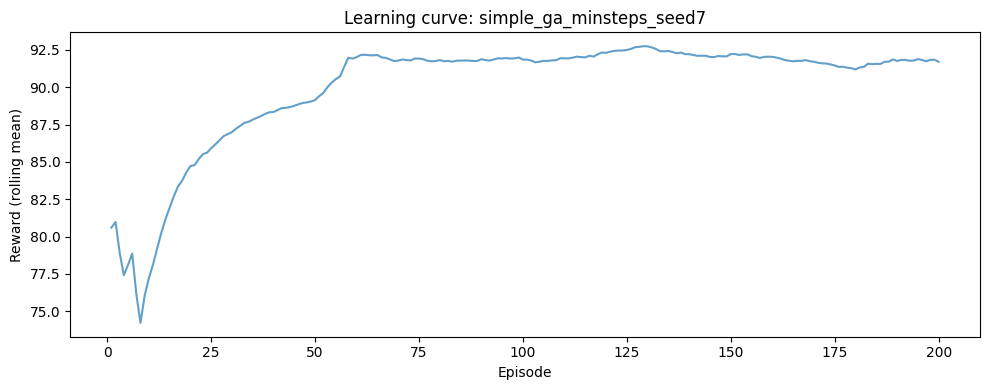

Saved C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\ga_simple_ga_minsteps_seed7_learning_curve.png


In [44]:
# Run the GA-style report to regenerate comparison figures (saves to outputs/figures)
plot_comparisons(logs_dir=PROJECT_ROOT / 'outputs' / 'logs', out_dir=PROJECT_ROOT / 'outputs' / 'figures')

In [45]:
# Utility helpers (seed, paths, logging)
def seed_everything(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)


def seed_env(env, seed: int) -> None:
    env.reset(seed=seed)
    if hasattr(env.action_space, 'seed'):
        env.action_space.seed(seed)
    if hasattr(env.observation_space, 'seed'):
        env.observation_space.seed(seed)


def ensure_paths(config: dict, project_root: Path) -> dict:
    root = Path(project_root)
    paths = config.get('paths', {})
    logs_dir = root / paths.get('logs_dir', 'outputs/logs')
    models_dir = root / paths.get('models_dir', 'outputs/models')
    figures_dir = root / paths.get('figures_dir', 'outputs/figures')
    logs_dir.mkdir(parents=True, exist_ok=True)
    models_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)
    return {'logs_dir': logs_dir, 'models_dir': models_dir, 'figures_dir': figures_dir}


def dump_json(data: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as f:
        json.dump(data, f, indent=2)


class _DummyWriter:
    def add_scalar(self, *args, **kwargs):
        pass
    def flush(self):
        pass
    def close(self):
        pass


def make_writer(log_root: Path, run_name: str):
    if not TORCH_AVAILABLE:
        return _DummyWriter()
    try:
        from torch.utils.tensorboard import SummaryWriter
        timestamp = time.strftime('%Y%m%d-%H%M%S')
        log_dir = Path(log_root) / f"{run_name}_{timestamp}"
        log_dir.mkdir(parents=True, exist_ok=True)
        return SummaryWriter(log_dir=str(log_dir))
    except Exception:
        return _DummyWriter()

In [46]:
# State utils and wrappers (from src/envs/state_utils.py and src/envs/wrappers.py)
from dataclasses import dataclass


@dataclass(frozen=True)
class StateBinner:
    low: np.ndarray
    high: np.ndarray
    n_bins: int

    def discretize(self, observation: np.ndarray) -> tuple[int, int]:
        obs = np.asarray(observation[:2], dtype=np.float32)
        ratio = (obs - self.low) / (self.high - self.low + 1e-12)
        clipped = np.clip(ratio, 0.0, 1.0)
        bins = np.floor(clipped * self.n_bins).astype(np.int64)
        bins = np.clip(bins, 0, self.n_bins - 1)
        return int(bins[0]), int(bins[1])

    def to_flat_index(self, state: tuple[int, int]) -> int:
        i, j = state
        return i * self.n_bins + j


def augment_state(observation: np.ndarray) -> np.ndarray:
    position = float(observation[0])
    velocity = float(observation[1])
    kinetic_energy = 0.5 * velocity * velocity
    potential_proxy = np.sin(3.0 * position)
    return np.array([position, velocity, kinetic_energy, potential_proxy], dtype=np.float32)


if not GYM_AVAILABLE:
    raise RuntimeError('gymnasium is required to run the environment wrappers.')


class DiscretizeStateWrapper(gym.ObservationWrapper):
    def __init__(self, env: gym.Env, n_bins: int = 20) -> None:
        super().__init__(env)
        if not isinstance(env.observation_space, gym.spaces.Box):
            raise TypeError('DiscretizeStateWrapper requires Box observation space.')
        self.n_bins = n_bins
        low = env.observation_space.low[:2].astype(np.float32)
        high = env.observation_space.high[:2].astype(np.float32)
        self.binner = StateBinner(low=low, high=high, n_bins=n_bins)
        self.observation_space = gym.spaces.MultiDiscrete(np.array([n_bins, n_bins]))

    def observation(self, observation: np.ndarray) -> tuple[int, int]:
        return self.binner.discretize(observation)

    @property
    def state_shape(self) -> tuple[int, int]:
        return (self.n_bins, self.n_bins)

    def obs_to_index(self, obs: tuple[int, int]) -> int:
        return self.binner.to_flat_index(obs)


class AugmentStateWrapper(gym.ObservationWrapper):
    def __init__(self, env: gym.Env) -> None:
        super().__init__(env)
        if not isinstance(env.observation_space, gym.spaces.Box):
            raise TypeError('AugmentStateWrapper requires Box observation space.')
        base_low = env.observation_space.low[:2].astype(np.float32)
        base_high = env.observation_space.high[:2].astype(np.float32)
        v_abs = float(max(abs(base_low[1]), abs(base_high[1])))
        kinetic_max = 0.5 * (v_abs ** 2)
        self.observation_space = gym.spaces.Box(
            low=np.array([base_low[0], base_low[1], 0.0, -1.0], dtype=np.float32),
            high=np.array([base_high[0], base_high[1], kinetic_max, 1.0], dtype=np.float32),
            shape=(4,),
            dtype=np.float32,
        )

    def observation(self, observation: np.ndarray) -> np.ndarray:
        return augment_state(observation)


class EnergyShapingRewardWrapper(gym.Wrapper):
    def __init__(self, env: gym.Env, energy_weight: float = 100.0) -> None:
        super().__init__(env)
        self.energy_weight = energy_weight

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        velocity = float(obs[1])
        shaped_reward = float(reward + self.energy_weight * abs(velocity))
        return obs, shaped_reward, terminated, truncated, info


class ProgressAndGoalRewardWrapper(gym.Wrapper):
    def __init__(self, env: gym.Env, progress_weight: float = 2.0, goal_bonus: float = 100.0) -> None:
        super().__init__(env)
        self.progress_weight = float(progress_weight)
        self.goal_bonus = float(goal_bonus)
        self._prev_position = 0.0

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_position = float(obs[0])
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        position = float(obs[0])
        progress = position - self._prev_position
        shaped_reward = float(reward + self.progress_weight * progress)
        if terminated and not truncated:
            shaped_reward += self.goal_bonus
        self._prev_position = position
        return obs, shaped_reward, terminated, truncated, info


class DiscreteFuelCostWrapper(gym.Wrapper):
    def step(self, action: int):
        obs, _, terminated, truncated, info = self.env.step(action)
        reward = -1.0 + (100.0 if terminated else 0.0)
        return obs, reward, terminated, truncated, info


class ContinuousStepCostWrapper(gym.Wrapper):
    def step(self, action: np.ndarray):
        obs, _, terminated, truncated, info = self.env.step(action)
        linear_cost = -0.1 * float(np.abs(np.asarray(action)).sum())
        reward = linear_cost + (100.0 if terminated else 0.0)
        return obs, reward, terminated, truncated, info


class RecordEpisodeStatsWrapper(gym.Wrapper):
    def __init__(self, env: gym.Env) -> None:
        super().__init__(env)
        self.episode_rewards = []
        self.episode_lengths = []
        self.episode_successes = []
        self._episode_reward = 0.0
        self._episode_length = 0

    def reset(self, **kwargs):
        self._episode_reward = 0.0
        self._episode_length = 0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._episode_reward += float(reward)
        self._episode_length += 1
        if terminated or truncated:
            self.episode_rewards.append(self._episode_reward)
            self.episode_lengths.append(self._episode_length)
            self.episode_successes.append(bool(terminated and not truncated))
        return obs, reward, terminated, truncated, info

    def get_stats(self) -> dict:
        if not self.episode_rewards:
            return {'mean_reward': 0.0, 'std_reward': 0.0, 'mean_length': 0.0, 'success_rate': 0.0}
        return {
            'mean_reward': float(np.mean(self.episode_rewards)),
            'std_reward': float(np.std(self.episode_rewards)),
            'mean_length': float(np.mean(self.episode_lengths)),
            'success_rate': float(np.mean(self.episode_successes)),
        }

    def reset_stats(self) -> None:
        self.episode_rewards.clear()
        self.episode_lengths.clear()
        self.episode_successes.clear()

In [47]:
# Environment builders (from src/envs/mountain_car_discrete.py and mountain_car_continuous.py)
def make_discrete_env(render_mode: str | None = None, wrappers: dict | None = None):
    env = gym.make('MountainCar-v0', render_mode=render_mode)
    wrappers = wrappers or {}

    if wrappers.get('discretize_state') and wrappers.get('augment_state'):
        raise ValueError('discretize_state and augment_state are mutually exclusive.')

    if wrappers.get('discretize_state'):
        kwargs = wrappers['discretize_state'] if isinstance(wrappers['discretize_state'], dict) else {}
        env = DiscretizeStateWrapper(env, **kwargs)

    if wrappers.get('augment_state'):
        env = AugmentStateWrapper(env)

    if wrappers.get('fuel_cost'):
        env = DiscreteFuelCostWrapper(env)

    if wrappers.get('energy_shaping'):
        kwargs = wrappers['energy_shaping'] if isinstance(wrappers['energy_shaping'], dict) else {}
        env = EnergyShapingRewardWrapper(env, **kwargs)

    if wrappers.get('progress_goal_reward'):
        kwargs = wrappers['progress_goal_reward'] if isinstance(wrappers['progress_goal_reward'], dict) else {}
        env = ProgressAndGoalRewardWrapper(env, **kwargs)

    if wrappers.get('record_episode_stats'):
        env = RecordEpisodeStatsWrapper(env)

    return env


def make_continuous_env(render_mode: str | None = None, wrappers: dict | None = None):
    env = gym.make('MountainCarContinuous-v0', render_mode=render_mode)
    wrappers = wrappers or {}

    if wrappers.get('step_cost'):
        env = ContinuousStepCostWrapper(env)

    if wrappers.get('energy_shaping'):
        kwargs = wrappers['energy_shaping'] if isinstance(wrappers['energy_shaping'], dict) else {}
        env = EnergyShapingRewardWrapper(env, **kwargs)

    if wrappers.get('record_episode_stats'):
        env = RecordEpisodeStatsWrapper(env)

    return env

In [48]:
# Policy network helpers (from src/agents/nn_policy.py)
class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim: int, n_out: int, hidden_sizes: list[int] = [64, 64]):
        super().__init__()
        layers = []
        in_dim = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, n_out))
        self.net = nn.Sequential(*layers)
        self.train(False)

    @property
    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def get_weights(self) -> np.ndarray:
        return np.concatenate([p.detach().cpu().numpy().ravel() for p in self.parameters()]).astype(np.float64)

    def set_weights(self, w: np.ndarray) -> None:
        with torch.no_grad():
            offset = 0
            for p in self.parameters():
                size = p.numel()
                p.copy_(torch.tensor(w[offset:offset + size], dtype=p.dtype).reshape(p.shape))
                offset += size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def batched_forward(self, obs_batch, all_weights):
        device = next(self.parameters()).device
        is_numpy = isinstance(obs_batch, np.ndarray)
        x = torch.from_numpy(obs_batch.astype(np.float32)).to(device) if is_numpy else obs_batch.float().to(device)
        w = torch.from_numpy(all_weights.astype(np.float32)).to(device) if isinstance(all_weights, np.ndarray) else all_weights.float().to(device)
        N = len(x)
        offset = 0
        with torch.no_grad():
            for layer in self.net:
                if isinstance(layer, nn.Linear):
                    out_dim, in_dim = layer.weight.shape
                    W = w[:, offset:offset + out_dim * in_dim].reshape(N, out_dim, in_dim)
                    offset += out_dim * in_dim
                    b = w[:, offset:offset + out_dim]
                    offset += out_dim
                    x = torch.bmm(W, x.unsqueeze(-1)).squeeze(-1) + b
                elif isinstance(layer, nn.ReLU):
                    x = torch.relu(x)
        return x.cpu().numpy() if is_numpy else x


def build_policy(env, hidden_sizes: list[int] = [64, 64]) -> PolicyNetwork:
    obs_dim = env.observation_space.shape[0]
    if isinstance(env.action_space, gym.spaces.Discrete):
        n_out = env.action_space.n
    else:
        n_out = env.action_space.shape[0]
    return PolicyNetwork(obs_dim, n_out, hidden_sizes)

In [49]:
# Q-learning and SARSA agents
class QLearningAgent:
    def __init__(self, n_bins: int, n_actions: int, learning_rate: float, gamma: float, epsilon_start: float, epsilon_end: float, epsilon_decay: float) -> None:
        self.n_bins = n_bins
        self.n_actions = n_actions
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.q_table = np.zeros((n_bins, n_bins, n_actions), dtype=np.float32)

    def select_action(self, state: tuple[int, int], deterministic: bool = False) -> int:
        if not deterministic and np.random.rand() < self.epsilon:
            return int(np.random.randint(self.n_actions))
        i, j = state
        return int(np.argmax(self.q_table[i, j]))

    def update(self, state: tuple[int, int], action: int, reward: float, next_state: tuple[int, int], done: bool) -> None:
        i, j = state
        ni, nj = next_state
        next_best = 0.0 if done else float(np.max(self.q_table[ni, nj]))
        target = reward + self.gamma * next_best
        td_error = target - self.q_table[i, j, action]
        self.q_table[i, j, action] += self.learning_rate * td_error

    def on_episode_end(self) -> None:
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def save(self, model_path: str | Path) -> None:
        path = Path(model_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(path, q_table=self.q_table, epsilon=self.epsilon)

    def load(self, model_path: str | Path) -> None:
        data = np.load(model_path)
        self.q_table = data['q_table']
        self.epsilon = float(data['epsilon'])

    @property
    def policy_table(self) -> np.ndarray:
        return np.argmax(self.q_table, axis=2)


class SarsaAgent:
    def __init__(self, n_bins: int, n_actions: int, learning_rate: float, gamma: float, epsilon_start: float, epsilon_end: float, epsilon_decay: float) -> None:
        self.n_bins = n_bins
        self.n_actions = n_actions
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.q_table = np.zeros((n_bins, n_bins, n_actions), dtype=np.float32)

    def select_action(self, state: tuple[int, int], deterministic: bool = False) -> int:
        if not deterministic and np.random.rand() < self.epsilon:
            return int(np.random.randint(self.n_actions))
        i, j = state
        return int(np.argmax(self.q_table[i, j]))

    def update(self, state: tuple[int, int], action: int, reward: float, next_state: tuple[int, int], next_action: int, done: bool) -> None:
        i, j = state
        ni, nj = next_state
        next_value = 0.0 if done else float(self.q_table[ni, nj, next_action])
        target = reward + self.gamma * next_value
        td_error = target - self.q_table[i, j, action]
        self.q_table[i, j, action] += self.learning_rate * td_error

    def on_episode_end(self) -> None:
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def policy_table(self) -> np.ndarray:
        return np.argmax(self.q_table, axis=2)

    def save(self, model_path: str | Path) -> None:
        path = Path(model_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(path, q_table=self.q_table, epsilon=self.epsilon)

    def load(self, model_path: str | Path) -> None:
        data = np.load(model_path)
        self.q_table = data['q_table']
        self.epsilon = float(data['epsilon'])

In [50]:
# Stable-Baselines3 adapters (DQN, SAC, PPO)
if SB3_AVAILABLE:
    class DQNBaseline:
        def __init__(self, env, learning_rate: float, gamma: float, epsilon_start: float, epsilon_end: float, epsilon_decay: float, batch_size: int, replay_buffer_size: int, learning_starts: int, target_update_freq: int, hidden_sizes: list[int], exploration_fraction: float | None = None) -> None:
            if exploration_fraction is None:
                exploration_fraction = min(1.0, max(1e-4, 1.0 - epsilon_decay))
            self.model = DQN(
                policy='MlpPolicy',
                env=env,
                learning_rate=learning_rate,
                gamma=gamma,
                exploration_initial_eps=epsilon_start,
                exploration_final_eps=epsilon_end,
                exploration_fraction=exploration_fraction,
                batch_size=batch_size,
                buffer_size=replay_buffer_size,
                learning_starts=learning_starts,
                target_update_interval=target_update_freq,
                policy_kwargs={'net_arch': hidden_sizes},
                verbose=0,
            )

        def learn(self, total_timesteps: int) -> None:
            self.model.learn(total_timesteps=total_timesteps, reset_num_timesteps=False)

        def predict(self, state: np.ndarray, deterministic: bool = True) -> int:
            action, _ = self.model.predict(state, deterministic=deterministic)
            return int(action)

        def save(self, model_path: str | Path) -> None:
            path = Path(model_path)
            path.parent.mkdir(parents=True, exist_ok=True)
            self.model.save(str(path))

        def load(self, model_path: str | Path, env) -> None:
            self.model = DQN.load(str(model_path), env=env)

        @property
        def exploration_rate(self) -> float:
            return float(self.model.exploration_rate)


    class SACBaseline:
        def __init__(self, env, learning_rate: float, gamma: float, tau: float, alpha: str | float, batch_size: int, replay_buffer_size: int, learning_starts: int, hidden_sizes: list[int]) -> None:
            self.model = SAC(
                policy='MlpPolicy',
                env=env,
                learning_rate=learning_rate,
                gamma=gamma,
                tau=tau,
                ent_coef=alpha,
                batch_size=batch_size,
                buffer_size=replay_buffer_size,
                learning_starts=learning_starts,
                policy_kwargs={'net_arch': hidden_sizes},
                verbose=0,
            )

        def learn(self, total_timesteps: int) -> None:
            self.model.learn(total_timesteps=total_timesteps, reset_num_timesteps=False)

        def predict(self, state: np.ndarray, deterministic: bool = True) -> np.ndarray:
            action, _ = self.model.predict(state, deterministic=deterministic)
            return np.asarray(action, dtype=np.float32)

        def save(self, model_path: str | Path) -> None:
            path = Path(model_path)
            path.parent.mkdir(parents=True, exist_ok=True)
            self.model.save(str(path))

        def load(self, model_path: str | Path, env) -> None:
            self.model = SAC.load(str(model_path), env=env)


    class PPOBaseline:
        def __init__(self, env, learning_rate: float, n_steps: int, batch_size: int, gamma: float, clip_range: float, ent_coef: float, hidden_sizes: list[int]) -> None:
            self.model = PPO(
                policy='MlpPolicy',
                env=env,
                learning_rate=learning_rate,
                n_steps=n_steps,
                batch_size=batch_size,
                gamma=gamma,
                clip_range=clip_range,
                ent_coef=ent_coef,
                policy_kwargs={'net_arch': hidden_sizes},
                verbose=0,
            )

        def learn(self, total_timesteps: int) -> None:
            self.model.learn(total_timesteps=total_timesteps, reset_num_timesteps=False)

        def predict(self, state: np.ndarray, deterministic: bool = True) -> np.ndarray:
            action, _ = self.model.predict(state, deterministic=deterministic)
            return np.asarray(action, dtype=np.float32)

        def save(self, model_path: str | Path) -> None:
            path = Path(model_path)
            path.parent.mkdir(parents=True, exist_ok=True)
            self.model.save(str(path))

        def load(self, model_path: str | Path, env) -> None:
            self.model = PPO.load(str(model_path), env=env)
else:
    class DQNBaseline:
        def __init__(self, *args, **kwargs):
            raise ImportError('stable-baselines3 is required for DQNBaseline')
    class SACBaseline:
        def __init__(self, *args, **kwargs):
            raise ImportError('stable-baselines3 is required for SACBaseline')
    class PPOBaseline:
        def __init__(self, *args, **kwargs):
            raise ImportError('stable-baselines3 is required for PPOBaseline')

In [51]:
# REINFORCE baseline (from src/agents/reinforce.py)
if TORCH_AVAILABLE:
    from torch.distributions import Categorical

    class ActorCriticNet(nn.Module):
        def __init__(self, input_dim: int, hidden_sizes: list[int], action_dim: int) -> None:
            super().__init__()
            layers = []
            prev = input_dim
            for hidden in hidden_sizes:
                layers.extend([nn.Linear(prev, hidden), nn.Tanh()])
                prev = hidden
            self.torso = nn.Sequential(*layers)
            self.policy_head = nn.Linear(prev, action_dim)
            self.value_head = nn.Linear(prev, 1)

        def forward(self, x: torch.Tensor):
            features = self.torso(x)
            return self.policy_head(features), self.value_head(features).squeeze(-1)


    class REINFORCEBaseline:
        def __init__(self, env, learning_rate: float, gamma: float, entropy_coef: float = 0.0, value_fn_coef: float = 0.5, hidden_sizes: list[int] | None = None, batch_episodes: int = 8, teacher_checkpoint: str | None = None, teacher_pretrain_episodes: int = 64) -> None:
            if hidden_sizes is None:
                hidden_sizes = [128, 128]
            if not hasattr(env.observation_space, 'shape') or env.observation_space.shape is None:
                raise ValueError('REINFORCE requires a flat observation space.')
            if not hasattr(env.action_space, 'n'):
                raise ValueError('REINFORCE requires a discrete action space.')

            self.env = env
            self.learning_rate = float(learning_rate)
            self.gamma = float(gamma)
            self.entropy_coef = float(entropy_coef)
            self.value_fn_coef = float(value_fn_coef)
            self.hidden_sizes = hidden_sizes
            self.batch_episodes = max(1, int(batch_episodes))
            self.input_dim = int(env.observation_space.shape[0])
            self.action_dim = int(env.action_space.n)
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

            self.net = ActorCriticNet(self.input_dim, hidden_sizes, self.action_dim).to(self.device)
            self.optimizer = optim.Adam(self.net.parameters(), lr=self.learning_rate)

            self.teacher_checkpoint = teacher_checkpoint
            self.teacher_model = None
            if teacher_checkpoint:
                if SB3_AVAILABLE:
                    self.teacher_model = DQNBaseline(
                        env=env,
                        learning_rate=1e-4,
                        gamma=self.gamma,
                        epsilon_start=0.0,
                        epsilon_end=0.0,
                        epsilon_decay=1.0,
                        batch_size=32,
                        replay_buffer_size=1000,
                        learning_starts=1,
                        target_update_freq=1,
                        hidden_sizes=hidden_sizes,
                        exploration_fraction=0.0,
                    )
                    self.teacher_model.load(teacher_checkpoint, env)
                self._pretrain_from_teacher(env, teacher_checkpoint, n_episodes=max(1, int(teacher_pretrain_episodes)))

        def _policy_distribution(self, state: np.ndarray):
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            logits, value = self.net(state_tensor)
            return Categorical(logits=logits), value.squeeze(0)

        def _discounted_returns(self, rewards: list[float]) -> torch.Tensor:
            returns = []
            running = 0.0
            for reward in reversed(rewards):
                running = float(reward) + self.gamma * running
                returns.append(running)
            returns.reverse()
            ret = torch.tensor(returns, dtype=torch.float32, device=self.device)
            if ret.numel() > 1:
                ret = (ret - ret.mean()) / (ret.std(unbiased=False) + 1e-8)
            return ret

        def _pretrain_from_teacher(self, env, teacher_checkpoint: str | None, n_episodes: int) -> None:
            if teacher_checkpoint is None or not SB3_AVAILABLE:
                return
            teacher = DQNBaseline(
                env=env,
                learning_rate=1e-4,
                gamma=self.gamma,
                epsilon_start=0.0,
                epsilon_end=0.0,
                epsilon_decay=1.0,
                batch_size=32,
                replay_buffer_size=1000,
                learning_starts=1,
                target_update_freq=1,
                hidden_sizes=self.hidden_sizes,
            )
            teacher.load(teacher_checkpoint, env)
            states = []
            actions = []
            for episode_idx in range(n_episodes):
                obs, _ = env.reset(seed=episode_idx)
                done = False
                steps = 0
                while not done and steps < 200:
                    action = teacher.predict(obs, deterministic=True)
                    states.append(np.asarray(obs, dtype=np.float32))
                    actions.append(int(action))
                    obs, _, terminated, truncated, _ = env.step(int(action))
                    done = bool(terminated or truncated)
                    steps += 1
            if not states:
                return
            state_tensor = torch.as_tensor(np.asarray(states), dtype=torch.float32, device=self.device)
            action_tensor = torch.as_tensor(np.asarray(actions), dtype=torch.long, device=self.device)
            for _ in range(20):
                logits, _ = self.net(state_tensor)
                loss = nn.functional.cross_entropy(logits, action_tensor)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

        def learn(self, total_timesteps: int) -> None:
            batch_log_probs = []
            batch_values = []
            batch_entropies = []
            batch_returns = []
            for episode_idx in range(self.batch_episodes):
                obs, _ = self.env.reset(seed=episode_idx)
                episode_log_probs = []
                episode_values = []
                episode_entropies = []
                episode_rewards = []
                done = False
                steps = 0
                while not done and steps < total_timesteps:
                    dist, value = self._policy_distribution(np.asarray(obs, dtype=np.float32))
                    action = dist.sample()
                    episode_log_probs.append(dist.log_prob(action))
                    episode_values.append(value)
                    episode_entropies.append(dist.entropy())
                    obs, reward, terminated, truncated, _ = self.env.step(int(action.item()))
                    episode_rewards.append(float(reward))
                    done = bool(terminated or truncated)
                    steps += 1
                if episode_rewards:
                    batch_log_probs.extend(episode_log_probs)
                    batch_values.extend(episode_values)
                    batch_entropies.extend(episode_entropies)
                    batch_returns.append(self._discounted_returns(episode_rewards))
            if not batch_returns:
                return
            returns = torch.cat(batch_returns)
            log_probs = torch.stack(batch_log_probs)
            values = torch.stack(batch_values)
            entropies = torch.stack(batch_entropies)
            advantages = returns - values.detach()
            policy_loss = -(log_probs * advantages).mean()
            value_loss = 0.5 * (returns - values).pow(2).mean()
            entropy_loss = -entropies.mean()
            loss = policy_loss + self.value_fn_coef * value_loss + self.entropy_coef * entropy_loss
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=1.0)
            self.optimizer.step()

        def predict(self, state: np.ndarray, deterministic: bool = True) -> int:
            if self.teacher_model is not None and deterministic:
                return int(self.teacher_model.predict(state, deterministic=True))
            dist, _ = self._policy_distribution(np.asarray(state, dtype=np.float32))
            if deterministic:
                return int(torch.argmax(dist.probs, dim=-1).item())
            return int(dist.sample().item())

        def save(self, checkpoint_path: str | Path) -> None:
            path = Path(checkpoint_path)
            path.parent.mkdir(parents=True, exist_ok=True)
            payload = {
                'state_dict': self.net.state_dict(),
                'input_dim': self.input_dim,
                'hidden_sizes': self.hidden_sizes,
                'action_dim': self.action_dim,
                'learning_rate': self.learning_rate,
                'gamma': self.gamma,
                'entropy_coef': self.entropy_coef,
                'value_fn_coef': self.value_fn_coef,
                'teacher_checkpoint': self.teacher_checkpoint,
            }
            torch.save(payload, str(path))

        def load(self, checkpoint_path: str | Path, env) -> None:
            payload = torch.load(str(checkpoint_path), map_location=self.device)
            self.input_dim = int(payload['input_dim'])
            self.hidden_sizes = list(payload['hidden_sizes'])
            self.action_dim = int(payload['action_dim'])
            self.learning_rate = float(payload['learning_rate'])
            self.gamma = float(payload['gamma'])
            self.entropy_coef = float(payload.get('entropy_coef', 0.0))
            self.value_fn_coef = float(payload.get('value_fn_coef', 0.5))
            self.teacher_checkpoint = payload.get('teacher_checkpoint')
            self.env = env
            self.net = ActorCriticNet(self.input_dim, self.hidden_sizes, self.action_dim).to(self.device)
            self.net.load_state_dict(payload['state_dict'])
            self.optimizer = optim.Adam(self.net.parameters(), lr=self.learning_rate)
            self.teacher_model = None
else:
    class REINFORCEBaseline:
        def __init__(self, *args, **kwargs):
            raise ImportError('PyTorch is required for REINFORCEBaseline')

In [52]:
# Evolutionary baselines (Simple GA, CMA-ES)
if TORCH_AVAILABLE:
    class SimpleGAAgent:
        def __init__(self, env, population_size: int = 50, elite_frac: float = 0.2, mutation_std: float = 0.05, crossover_alpha: float = 0.5, hidden_sizes: list[int] = [64, 64]) -> None:
            self._env = env
            self._net = build_policy(env, hidden_sizes)
            self._discrete = isinstance(env.action_space, gym.spaces.Discrete)
            self._augment = env.observation_space.shape[0] == 4
            self._action_scale = float(env.action_space.high[0]) if not self._discrete else 1.0
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            self._net.to(self.device)

            self._population_size = population_size
            self._elite_frac = elite_frac
            self._mutation_std = mutation_std
            self._crossover_alpha = crossover_alpha
            self._hidden_sizes = hidden_sizes
            self._rng = np.random.default_rng()
            self._envs = None
            base_w = torch.from_numpy(self._net.get_weights().astype(np.float32)).to(self.device)
            self._pop = base_w + torch.randn(population_size, self._net.n_params, device=self.device) * 0.5
            self._best_weights = None
            self._best_fitness = -np.inf

        def _get_envs(self, n: int) -> list:
            if self._envs is None or len(self._envs) != n:
                import copy
                self._envs = [copy.deepcopy(self._env) for _ in range(n)]
            return self._envs

        def _eval_population(self, weights_matrix, max_steps: int) -> list[float]:
            N = len(weights_matrix)
            envs = self._get_envs(N)
            obs = np.array([env.reset()[0] for env in envs], dtype=np.float32)
            total_rewards = np.zeros(N)
            active = np.ones(N, dtype=bool)
            for _ in range(max_steps):
                if not active.any():
                    break
                idx = np.where(active)[0]
                logits = self._net.batched_forward(obs[idx], weights_matrix[idx])
                if self._discrete:
                    actions = np.argmax(logits, axis=1)
                else:
                    actions = (np.tanh(logits) * self._action_scale).astype(np.float32)
                for j, i in enumerate(idx):
                    act = int(actions[j]) if self._discrete else actions[j]
                    next_obs, reward, terminated, truncated, _ = envs[i].step(act)
                    total_rewards[i] += float(reward)
                    obs[i] = next_obs
                    if terminated or truncated:
                        active[i] = False
            return total_rewards.tolist()

        def learn(self, total_timesteps: int) -> None:
            fitnesses = self._eval_population(self._pop, total_timesteps)
            n_params = self._net.n_params
            new_pop = torch.empty((self._population_size, n_params), dtype=torch.float32, device=self.device)
            ranked_idx = np.argsort(fitnesses)[::-1].copy()
            n_elite = max(1, int(self._population_size * self._elite_frac))
            elites = self._pop[ranked_idx[:n_elite]]
            new_pop[:n_elite] = elites

            tournament_size = 3
            def tournament_select():
                contenders = torch.randint(0, self._population_size, (tournament_size,), device=self.device)
                best_idx = contenders[int(np.argmax([fitnesses[idx] for idx in contenders]))]
                return self._pop[best_idx]

            for i in range(n_elite, self._population_size):
                parent_a = tournament_select()
                parent_b = tournament_select()
                crossover_mask = torch.rand(n_params, device=self.device) < 0.5
                child = torch.where(crossover_mask, parent_a, parent_b)
                mutate_mask = torch.rand(n_params, device=self.device) < 0.1
                mutation = torch.randn(n_params, device=self.device) * self._mutation_std
                child[mutate_mask] += mutation[mutate_mask]
                new_pop[i] = child
            self._pop = new_pop

            best_fitness = max(fitnesses)
            if best_fitness > self._best_fitness:
                self._best_fitness = best_fitness
                self._best_weights = elites[0].cpu().numpy().copy()
            self._net.set_weights(self._best_weights)

        def predict(self, obs: np.ndarray, deterministic: bool = True):
            if self._best_weights is None:
                self._net.set_weights(self._pop[0].cpu().numpy())
            tensor = torch.from_numpy(np.asarray(obs, dtype=np.float32)).to(self.device)
            with torch.no_grad():
                logits = self._net(tensor)
            if self._discrete:
                return int(np.argmax(logits.cpu().numpy()))
            return (np.tanh(logits.cpu().numpy()) * self._action_scale).astype(np.float32).reshape(-1)

        def save(self, model_path: str | Path) -> None:
            path = Path(model_path).with_suffix('.npz')
            path.parent.mkdir(parents=True, exist_ok=True)
            np.savez_compressed(
                path,
                population=self._pop.cpu().numpy(),
                best_weights=self._best_weights if self._best_weights is not None else np.array([]),
                best_fitness=np.array([self._best_fitness]),
            )

        def load(self, model_path: str | Path, env=None) -> None:
            data = np.load(Path(model_path).with_suffix('.npz'), allow_pickle=False)
            self._pop = torch.from_numpy(data['population'].astype(np.float32)).to(self.device)
            w = data['best_weights']
            self._best_weights = w if w.size > 0 else None
            self._best_fitness = float(data['best_fitness'][0])
            if self._best_weights is not None:
                self._net.set_weights(self._best_weights)

        @property
        def policy_table(self):
            if not self._discrete:
                return None
            pos_bins = np.linspace(-1.2, 0.6, 24)
            vel_bins = np.linspace(-0.07, 0.07, 24)
            table = np.zeros((24, 24), dtype=np.int32)
            with torch.no_grad():
                for i, pos in enumerate(pos_bins):
                    for j, vel in enumerate(vel_bins):
                        obs = np.array([pos, vel], dtype=np.float32)
                        if self._augment:
                            obs = augment_state(obs)
                        tensor_obs = torch.from_numpy(obs).to(self.device)
                        logits = self._net(tensor_obs)
                        table[i, j] = int(np.argmax(logits.cpu().numpy()))
            return table
else:
    class SimpleGAAgent:
        def __init__(self, *args, **kwargs):
            raise ImportError('PyTorch is required for SimpleGAAgent')


if CMA_AVAILABLE and TORCH_AVAILABLE:
    class CMAESAgent:
        def __init__(self, env, population_size: int = 50, sigma0: float = 0.5, hidden_sizes: list[int] = [64, 64]) -> None:
            self._env = env
            self._net = build_policy(env, hidden_sizes)
            self._discrete = isinstance(env.action_space, gym.spaces.Discrete)
            self._augment = env.observation_space.shape[0] == 4
            self._action_scale = float(env.action_space.high[0]) if not self._discrete else 1.0
            self._es = cma.CMAEvolutionStrategy(self._net.get_weights(), sigma0, {'popsize': population_size, 'verbose': -9})
            self._best_weights = None
            self._best_fitness = -np.inf
            self._envs = None

        def _get_envs(self, n: int) -> list:
            if self._envs is None or len(self._envs) != n:
                import copy
                self._envs = [copy.deepcopy(self._env) for _ in range(n)]
            return self._envs

        def _eval_population(self, weights_matrix: np.ndarray, max_steps: int) -> list[float]:
            N = len(weights_matrix)
            envs = self._get_envs(N)
            obs = np.array([env.reset()[0] for env in envs], dtype=np.float32)
            total_rewards = np.zeros(N)
            active = np.ones(N, dtype=bool)
            for _ in range(max_steps):
                if not active.any():
                    break
                idx = np.where(active)[0]
                logits = self._net.batched_forward(obs[idx], weights_matrix[idx])
                if self._discrete:
                    actions = np.argmax(logits, axis=1)
                else:
                    actions = (np.tanh(logits) * self._action_scale).astype(np.float32)
                for j, i in enumerate(idx):
                    act = int(actions[j]) if self._discrete else actions[j]
                    next_obs, reward, terminated, truncated, _ = envs[i].step(act)
                    total_rewards[i] += float(reward)
                    obs[i] = next_obs
                    if terminated or truncated:
                        active[i] = False
            return total_rewards.tolist()

        def learn(self, total_timesteps: int) -> None:
            solutions = self._es.ask()
            weights_matrix = np.array(solutions)
            fitnesses = self._eval_population(weights_matrix, total_timesteps)
            self._es.tell(solutions, [-f for f in fitnesses])
            best_idx = int(np.argmax(fitnesses))
            best_fitness = fitnesses[best_idx]
            if best_fitness > self._best_fitness:
                self._best_fitness = best_fitness
                self._best_weights = weights_matrix[best_idx].copy()
            if self._best_weights is not None:
                self._net.set_weights(self._best_weights)

        def predict(self, obs: np.ndarray, deterministic: bool = True):
            if self._best_weights is None:
                self._net.set_weights(np.zeros(self._net.n_params))
            tensor = torch.from_numpy(np.asarray(obs, dtype=np.float32))
            with torch.no_grad():
                logits = self._net(tensor)
            if self._discrete:
                return int(np.argmax(logits.numpy()))
            return (np.tanh(logits.numpy()) * self._action_scale).astype(np.float32).reshape(-1)

        def save(self, model_path: str | Path) -> None:
            path = Path(model_path).with_suffix('.npz')
            path.parent.mkdir(parents=True, exist_ok=True)
            np.savez_compressed(
                path,
                best_weights=self._best_weights if self._best_weights is not None else np.array([]),
                best_fitness=np.array([self._best_fitness]),
                cma_mean=self._es.mean.copy(),
                cma_sigma=np.array([self._es.sigma]),
                cma_C=self._es.sm.C.copy(),
                cma_B=self._es.sm.B.copy(),
                cma_D=np.atleast_1d(self._es.sm.D).copy(),
                cma_count_tell=np.array([self._es.sm.count_tell], dtype=np.int64),
                cma_popsize=np.array([self._es.popsize], dtype=np.int64),
            )

        def load(self, model_path: str | Path, env=None) -> None:
            data = np.load(Path(model_path).with_suffix('.npz'), allow_pickle=False)
            w = data['best_weights']
            self._best_weights = w if w.size > 0 else None
            self._best_fitness = float(data['best_fitness'][0])
            if self._best_weights is not None:
                self._net.set_weights(self._best_weights)
            mean = data['cma_mean']
            sigma = float(data['cma_sigma'][0])
            popsize = int(data['cma_popsize'][0])
            self._es = cma.CMAEvolutionStrategy(mean, sigma, {'popsize': popsize, 'verbose': -9})
            self._es.sm.C = data['cma_C'].copy()
            self._es.sm.B = data['cma_B'].copy()
            self._es.sm.D = data['cma_D'].copy()
            self._es.sm.count_tell = int(data['cma_count_tell'][0])

        @property
        def policy_table(self):
            if not self._discrete:
                return None
            pos_bins = np.linspace(-1.2, 0.6, 24)
            vel_bins = np.linspace(-0.07, 0.07, 24)
            table = np.zeros((24, 24), dtype=np.int32)
            with torch.no_grad():
                for i, pos in enumerate(pos_bins):
                    for j, vel in enumerate(vel_bins):
                        obs = np.array([pos, vel], dtype=np.float32)
                        if self._augment:
                            obs = augment_state(obs)
                        logits = self._net(torch.from_numpy(obs))
                        table[i, j] = int(np.argmax(logits.numpy()))
            return table
else:
    class CMAESAgent:
        def __init__(self, *args, **kwargs):
            raise ImportError('cma and PyTorch are required for CMAESAgent')

In [53]:
# NEAT agent (from src/agents/neat_agent.py, embedded templates)
_NEAT_DISCRETE_TEMPLATE = """[NEAT]\nfitness_criterion     = max\nfitness_threshold     = 90.0\npop_size              = 50\nreset_on_extinction   = False\nno_fitness_termination = True\n\n[DefaultGenome]\nactivation_default      = relu\nactivation_mutate_rate  = 0.05\nactivation_options      = relu tanh sigmoid\naggregation_default     = sum\naggregation_mutate_rate = 0.0\naggregation_options     = sum\nbias_init_mean          = 0.0\nbias_init_stdev         = 1.0\nbias_max_value          = 30.0\nbias_min_value          = -30.0\nbias_mutate_power       = 0.5\nbias_mutate_rate        = 0.7\nbias_replace_rate       = 0.1\ncompatibility_disjoint_coefficient = 1.0\ncompatibility_weight_coefficient   = 0.5\nconn_add_prob           = 0.1\nconn_delete_prob        = 0.05\nenabled_default         = True\nenabled_mutate_rate     = 0.01\nfeed_forward            = True\ninitial_connection      = full_direct\nnode_add_prob           = 0.05\nnode_delete_prob        = 0.05\nnum_hidden              = 0\nnum_inputs              = 2\nnum_outputs             = 3\nresponse_init_mean      = 1.0\nresponse_init_stdev     = 0.0\nresponse_max_value      = 30.0\nresponse_min_value      = -30.0\nresponse_mutate_power   = 0.0\nresponse_mutate_rate    = 0.0\nresponse_replace_rate   = 0.0\nweight_init_mean        = 0.0\nweight_init_stdev       = 1.0\nweight_max_value        = 30.0\nweight_min_value        = -30.0\nweight_mutate_power     = 0.5\nweight_mutate_rate      = 0.8\nweight_replace_rate     = 0.1\n\n[DefaultSpeciesSet]\ncompatibility_threshold = 3.0\n\n[DefaultStagnation]\nspecies_fitness_func = max\nmax_stagnation       = 50\nspecies_elitism      = 2\n\n[DefaultReproduction]\nelitism            = 4\nsurvival_threshold = 0.2\n"""
_NEAT_CONTINUOUS_TEMPLATE = """[NEAT]\nfitness_criterion     = max\nfitness_threshold     = 90.0\npop_size              = 50\nreset_on_extinction   = False\nno_fitness_termination = True\n\n[DefaultGenome]\nactivation_default      = tanh\nactivation_mutate_rate  = 0.05\nactivation_options      = relu tanh\naggregation_default     = sum\naggregation_mutate_rate = 0.0\naggregation_options     = sum\nbias_init_mean          = 0.0\nbias_init_stdev         = 1.0\nbias_max_value          = 30.0\nbias_min_value          = -30.0\nbias_mutate_power       = 0.5\nbias_mutate_rate        = 0.7\nbias_replace_rate       = 0.1\ncompatibility_disjoint_coefficient = 1.0\ncompatibility_weight_coefficient   = 0.5\nconn_add_prob           = 0.1\nconn_delete_prob        = 0.05\nenabled_default         = True\nenabled_mutate_rate     = 0.01\nfeed_forward            = True\ninitial_connection      = full_direct\nnode_add_prob           = 0.05\nnode_delete_prob        = 0.05\nnum_hidden              = 0\nnum_inputs              = 2\nnum_outputs             = 1\nresponse_init_mean      = 1.0\nresponse_init_stdev     = 0.0\nresponse_max_value      = 30.0\nresponse_min_value      = -30.0\nresponse_mutate_power   = 0.0\nresponse_mutate_rate    = 0.0\nresponse_replace_rate   = 0.0\nweight_init_mean        = 0.0\nweight_init_stdev       = 1.0\nweight_max_value        = 30.0\nweight_min_value        = -30.0\nweight_mutate_power     = 0.5\nweight_mutate_rate      = 0.8\nweight_replace_rate     = 0.1\n\n[DefaultSpeciesSet]\ncompatibility_threshold = 3.0\n\n[DefaultStagnation]\nspecies_fitness_func = max\nmax_stagnation       = 50\nspecies_elitism      = 2\n\n[DefaultReproduction]\nelitism            = 4\nsurvival_threshold = 0.2\n"""

if NEAT_AVAILABLE:
    import configparser
    import tempfile
    from math import inf

    class NeatAgent:
        def __init__(self, env, pop_size: int = 50, fitness_threshold: float = 90.0, hidden_sizes=None) -> None:
            self._env = env
            self._discrete = isinstance(env.action_space, gym.spaces.Discrete)
            self._augment = env.observation_space.shape[0] == 4
            self._action_scale = float(env.action_space.high[0]) if not self._discrete else 1.0
            num_inputs = env.observation_space.shape[0]
            num_outputs = env.action_space.n if self._discrete else env.action_space.shape[0]
            template = _NEAT_DISCRETE_TEMPLATE if self._discrete else _NEAT_CONTINUOUS_TEMPLATE
            self._config = self._build_config(template, num_inputs, num_outputs, pop_size, fitness_threshold)
            self._population = neat.Population(self._config)
            self._best_genome = None
            self._best_fitness = -inf
            self._net_cache = {}
            self._generation = 0
            self._genome_history = []

        def _build_config(self, template_str: str, num_inputs: int, num_outputs: int, pop_size: int, fitness_threshold: float):
            parser = configparser.ConfigParser()
            parser.read_string(template_str)
            parser['NEAT']['pop_size'] = str(pop_size)
            parser['NEAT']['fitness_threshold'] = str(fitness_threshold)
            parser['DefaultGenome']['num_inputs'] = str(num_inputs)
            parser['DefaultGenome']['num_outputs'] = str(num_outputs)
            tmp = tempfile.NamedTemporaryFile(mode='w', suffix='.ini', delete=False)
            parser.write(tmp)
            tmp.flush()
            tmp_path = tmp.name
            tmp.close()
            config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction, neat.DefaultSpeciesSet, neat.DefaultStagnation, tmp_path)
            Path(tmp_path).unlink(missing_ok=True)
            return config

        def _activate(self, genome, obs: np.ndarray):
            gid = id(genome)
            if gid not in self._net_cache:
                self._net_cache[gid] = neat.nn.FeedForwardNetwork.create(genome, self._config)
            return self._net_cache[gid].activate(obs.tolist())

        def _eval_genome(self, genome, max_steps: int) -> float:
            obs, _ = self._env.reset()
            total_reward = 0.0
            for _ in range(max_steps):
                output = self._activate(genome, obs)
                if self._discrete:
                    action = int(np.argmax(output))
                else:
                    action = np.clip(np.array(output, dtype=np.float32) * self._action_scale, -1.0, 1.0)
                obs, reward, terminated, truncated, _ = self._env.step(action)
                total_reward += float(reward)
                if terminated or truncated:
                    break
            return total_reward

        def learn(self, total_timesteps: int) -> None:
            self._net_cache.clear()
            def eval_genomes(genomes, config):
                for genome_id, genome in genomes:
                    genome.fitness = self._eval_genome(genome, total_timesteps)
            self._population.run(eval_genomes, 1)
            best = max(self._population.population.values(), key=lambda g: g.fitness if g.fitness is not None else -inf)
            if best.fitness is not None and best.fitness > self._best_fitness:
                self._best_fitness = float(best.fitness)
                self._best_genome = best
            self._generation += 1
            if self._best_genome is not None:
                import copy
                self._genome_history.append((self._generation, copy.deepcopy(self._best_genome)))

        def predict(self, obs: np.ndarray, deterministic: bool = True):
            if self._best_genome is None:
                genome = next(iter(self._population.population.values()))
            else:
                genome = self._best_genome
            output = self._activate(genome, np.asarray(obs, dtype=np.float32))
            if self._discrete:
                return int(np.argmax(output))
            return np.clip(np.array(output, dtype=np.float32) * self._action_scale, -1.0, 1.0).reshape(-1)

        def save(self, model_path: str | Path) -> None:
            path = Path(model_path).with_suffix('.json')
            path.parent.mkdir(parents=True, exist_ok=True)
            if self._best_genome is None:
                data = {'best_fitness': self._best_fitness, 'nodes': [], 'connections': []}
            else:
                g = self._best_genome
                nodes = [{'key': k, 'bias': v.bias, 'response': v.response, 'activation': v.activation} for k, v in g.nodes.items()]
                connections = [{'key': list(k), 'weight': v.weight, 'enabled': v.enabled, 'innovation': v.innovation} for k, v in g.connections.items()]
                data = {'best_fitness': self._best_fitness, 'nodes': nodes, 'connections': connections}
            path.write_text(json.dumps(data))

        def load(self, model_path: str | Path, env=None) -> None:
            path = Path(model_path).with_suffix('.json')
            data = json.loads(path.read_text())
            self._best_fitness = float(data['best_fitness'])
            if not data['nodes']:
                return
            genome = neat.DefaultGenome(0)
            genome.configure_new(self._config.genome_config)
            genome.nodes.clear()
            genome.connections.clear()
            for n in data['nodes']:
                node = neat.genes.DefaultNodeGene(n['key'])
                node.bias = float(n['bias'])
                node.response = float(n['response'])
                node.activation = n['activation']
                node.aggregation = 'sum'
                genome.nodes[n['key']] = node
            for c in data['connections']:
                key = tuple(c['key'])
                conn = neat.genes.DefaultConnectionGene(key, innovation=int(c['innovation']))
                conn.weight = float(c['weight'])
                conn.enabled = bool(c['enabled'])
                genome.connections[key] = conn
            genome.fitness = self._best_fitness
            self._best_genome = genome
else:
    class NeatAgent:
        def __init__(self, *args, **kwargs):
            raise ImportError('neat-python is required for NeatAgent')

In [54]:
# Training helpers (adapted from src/training/train.py, with SARSA support)
def build_env(env_cfg: dict, render_mode: str | None = None):
    env_id = env_cfg['id']
    wrappers = env_cfg.get('wrappers', {})
    if env_id == 'MountainCar-v0':
        return make_discrete_env(render_mode=render_mode, wrappers=wrappers)
    if env_id == 'MountainCarContinuous-v0':
        return make_continuous_env(render_mode=render_mode, wrappers=wrappers)
    raise ValueError(f'Unsupported environment id: {env_id}')


def build_agent(config: dict, env):
    agent_name = config['agent']
    if agent_name == 'q_learning':
        q_cfg = config['q_learning']
        wrappers = config['env'].get('wrappers', {})
        n_bins = wrappers.get('discretize_state', {}).get('n_bins')
        if n_bins is None:
            raise ValueError('Q-learning requires env.wrappers.discretize_state.n_bins')
        return QLearningAgent(
            n_bins=int(n_bins),
            n_actions=int(env.action_space.n),
            learning_rate=float(q_cfg['learning_rate']),
            gamma=float(q_cfg['gamma']),
            epsilon_start=float(q_cfg['epsilon_start']),
            epsilon_end=float(q_cfg['epsilon_end']),
            epsilon_decay=float(q_cfg['epsilon_decay']),
        )
    if agent_name == 'sarsa':
        s_cfg = config['sarsa']
        wrappers = config['env'].get('wrappers', {})
        n_bins = wrappers.get('discretize_state', {}).get('n_bins')
        if n_bins is None:
            raise ValueError('SARSA requires env.wrappers.discretize_state.n_bins')
        return SarsaAgent(
            n_bins=int(n_bins),
            n_actions=int(env.action_space.n),
            learning_rate=float(s_cfg['learning_rate']),
            gamma=float(s_cfg['gamma']),
            epsilon_start=float(s_cfg['epsilon_start']),
            epsilon_end=float(s_cfg['epsilon_end']),
            epsilon_decay=float(s_cfg['epsilon_decay']),
        )
    if agent_name == 'dqn':
        dqn_cfg = config['dqn']
        return DQNBaseline(
            env=env,
            learning_rate=float(dqn_cfg['learning_rate']),
            gamma=float(dqn_cfg['gamma']),
            epsilon_start=float(dqn_cfg['epsilon_start']),
            epsilon_end=float(dqn_cfg['epsilon_end']),
            epsilon_decay=float(dqn_cfg['epsilon_decay']),
            batch_size=int(dqn_cfg['batch_size']),
            replay_buffer_size=int(dqn_cfg['replay_buffer_size']),
            learning_starts=int(dqn_cfg.get('min_buffer_size', 1000)),
            target_update_freq=int(dqn_cfg['target_update_freq']),
            hidden_sizes=list(dqn_cfg['hidden_sizes']),
            exploration_fraction=float(dqn_cfg['exploration_fraction']) if 'exploration_fraction' in dqn_cfg else None,
        )
    if agent_name == 'reinforce':
        r_cfg = config['reinforce']
        return REINFORCEBaseline(
            env=env,
            learning_rate=float(r_cfg['learning_rate']),
            gamma=float(r_cfg['gamma']),
            entropy_coef=float(r_cfg.get('entropy_coef', 0.01)),
            value_fn_coef=float(r_cfg.get('value_fn_coef', 0.5)),
            hidden_sizes=list(r_cfg.get('hidden_sizes', [128, 128])),
            batch_episodes=int(r_cfg.get('batch_episodes', 8)),
            teacher_checkpoint=r_cfg.get('teacher_checkpoint'),
            teacher_pretrain_episodes=int(r_cfg.get('teacher_pretrain_episodes', 64)),
        )
    if agent_name == 'sac':
        s_cfg = config['sac']
        return SACBaseline(
            env=env,
            learning_rate=float(s_cfg['learning_rate']),
            gamma=float(s_cfg['gamma']),
            tau=float(s_cfg['tau']),
            alpha=s_cfg['alpha'],
            batch_size=int(s_cfg['batch_size']),
            replay_buffer_size=int(s_cfg['replay_buffer_size']),
            learning_starts=int(s_cfg['learning_starts']),
            hidden_sizes=list(s_cfg['hidden_sizes']),
        )
    if agent_name == 'ppo':
        p_cfg = config['ppo']
        return PPOBaseline(
            env=env,
            learning_rate=float(p_cfg['learning_rate']),
            n_steps=int(p_cfg['n_steps']),
            batch_size=int(p_cfg['batch_size']),
            gamma=float(p_cfg['gamma']),
            clip_range=float(p_cfg['clip_range']),
            ent_coef=float(p_cfg['ent_coef']),
            hidden_sizes=list(p_cfg['hidden_sizes']),
        )
    if agent_name == 'simple_ga':
        ga_cfg = config['simple_ga']
        return SimpleGAAgent(
            env=env,
            population_size=int(ga_cfg['population_size']),
            elite_frac=float(ga_cfg['elite_frac']),
            mutation_std=float(ga_cfg['mutation_std']),
            crossover_alpha=float(ga_cfg.get('crossover_alpha', 0.5)),
            hidden_sizes=list(ga_cfg.get('hidden_sizes', [64, 64])),
        )
    if agent_name == 'cma_es':
        c_cfg = config['cma_es']
        return CMAESAgent(
            env=env,
            population_size=int(c_cfg['population_size']),
            sigma0=float(c_cfg['sigma0']),
            hidden_sizes=list(c_cfg.get('hidden_sizes', [64, 64])),
        )
    if agent_name == 'neat':
        n_cfg = config['neat']
        return NeatAgent(
            env=env,
            pop_size=int(n_cfg['pop_size']),
            fitness_threshold=float(n_cfg.get('fitness_threshold', 90.0)),
        )
    raise ValueError(f'Unsupported agent type: {agent_name}')


def rollout_episode(env, agent, deterministic: bool = True) -> tuple[float, int, bool]:
    obs, _ = env.reset()
    done = False
    total_reward = 0.0
    steps = 0
    success = False
    while not done:
        if isinstance(agent, (QLearningAgent, SarsaAgent)):
            action = agent.select_action(tuple(obs), deterministic=deterministic)
        else:
            action = agent.predict(obs, deterministic=deterministic)
        if isinstance(env.action_space, gym.spaces.Discrete):
            action_to_env = int(action)
        else:
            action_to_env = np.asarray(action, dtype=np.float32)
        obs, reward, terminated, truncated, _ = env.step(action_to_env)
        total_reward += float(reward)
        steps += 1
        done = bool(terminated or truncated)
        success = bool(terminated and not truncated)
    return total_reward, steps, success


def train_single_seed(config: dict, seed: int, project_root: Path) -> dict:
    output_paths = ensure_paths(config, project_root)
    seed_everything(seed)
    env = build_env(config['env'])
    seed_env(env, seed)
    agent = build_agent(config, env)

    run_name = f"{config['experiment_name']}_seed{seed}"
    writer = make_writer(output_paths['logs_dir'], run_name)

    train_cfg = config['train']
    episodes = int(train_cfg['episodes'])
    max_steps = int(train_cfg['max_steps_per_episode'])
    eval_every = int(train_cfg.get('eval_every', 100))
    eval_episodes = int(train_cfg.get('eval_episodes', 20))
    save_every = int(train_cfg.get('save_every', episodes))

    rewards = []
    lengths = []
    successes = []
    eval_mean_rewards = []

    for episode in range(1, episodes + 1):
        if isinstance(agent, QLearningAgent):
            obs, _ = env.reset()
            state = tuple(obs)
            done = False
            ep_reward = 0.0
            ep_len = 0
            ep_success = False
            while not done and ep_len < max_steps:
                action = agent.select_action(state)
                next_obs, reward, terminated, truncated, _ = env.step(int(action))
                next_state = tuple(next_obs)
                done = bool(terminated or truncated)
                agent.update(state, int(action), float(reward), next_state, done)
                state = next_state
                ep_reward += float(reward)
                ep_len += 1
                ep_success = bool(terminated and not truncated)
            agent.on_episode_end()
        elif isinstance(agent, SarsaAgent):
            obs, _ = env.reset()
            state = tuple(obs)
            action = agent.select_action(state)
            done = False
            ep_reward = 0.0
            ep_len = 0
            ep_success = False
            while not done and ep_len < max_steps:
                next_obs, reward, terminated, truncated, _ = env.step(int(action))
                next_state = tuple(next_obs)
                done = bool(terminated or truncated)
                next_action = 0 if done else agent.select_action(next_state)
                agent.update(state, int(action), float(reward), next_state, int(next_action), done)
                state = next_state
                action = next_action
                ep_reward += float(reward)
                ep_len += 1
                ep_success = bool(terminated and not truncated)
            agent.on_episode_end()
        else:
            agent.learn(total_timesteps=max_steps)
            ep_reward, ep_len, ep_success = rollout_episode(env, agent, deterministic=True)

        rewards.append(ep_reward)
        lengths.append(ep_len)
        successes.append(float(ep_success))

        writer.add_scalar('train/reward', ep_reward, episode)
        writer.add_scalar('train/episode_length', ep_len, episode)
        writer.add_scalar('train/success', float(ep_success), episode)
        if isinstance(agent, QLearningAgent) or isinstance(agent, SarsaAgent):
            writer.add_scalar('train/epsilon', agent.epsilon, episode)
        elif hasattr(agent, 'exploration_rate'):
            writer.add_scalar('train/exploration_rate', agent.exploration_rate, episode)

        if episode % eval_every == 0:
            eval_rewards = []
            eval_success = []
            for _ in range(eval_episodes):
                r, _, s = rollout_episode(env, agent, deterministic=True)
                eval_rewards.append(r)
                eval_success.append(float(s))
            mean_eval_reward = float(np.mean(eval_rewards))
            mean_eval_success = float(np.mean(eval_success))
            eval_mean_rewards.append(mean_eval_reward)
            writer.add_scalar('eval/mean_reward', mean_eval_reward, episode)
            writer.add_scalar('eval/success_rate', mean_eval_success, episode)

        if episode % save_every == 0:
            checkpoint = output_paths['models_dir'] / f"{run_name}_ep{episode}"
            agent.save(checkpoint)

    final_model_path = output_paths['models_dir'] / f"{run_name}_final"
    agent.save(final_model_path)

    metrics = {
        'experiment_name': config['experiment_name'],
        'seed': seed,
        'agent': config['agent'],
        'env_id': config['env']['id'],
        'reward_mean': float(np.mean(rewards)),
        'reward_std': float(np.std(rewards)),
        'success_rate': float(np.mean(successes)),
        'mean_episode_length': float(np.mean(lengths)),
        'eval_mean_reward_last': float(eval_mean_rewards[-1] if eval_mean_rewards else np.mean(rewards)),
        'final_model_path': str(final_model_path),
    }

    per_episode_df = pd.DataFrame({
        'episode': np.arange(1, episodes + 1),
        'reward': rewards,
        'length': lengths,
        'success': successes,
        'seed': seed,
    })
    csv_path = output_paths['logs_dir'] / f"{run_name}_episodes.csv"
    per_episode_df.to_csv(csv_path, index=False)
    dump_json(metrics, output_paths['logs_dir'] / f"{run_name}_summary.json")

    writer.flush()
    writer.close()
    env.close()
    return metrics

In [ ]:
# Config loading and selection
def load_config(config_path: str | Path) -> dict:
    path = Path(config_path)
    if not YAML_AVAILABLE:
        raise RuntimeError('pyyaml is required to load config files.')
    with path.open('r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    if not isinstance(config, dict):
        raise ValueError('Configuration file must contain a YAML mapping.')
    return config


def embedded_configs() -> list[dict]:
    return [
        {
            'experiment_name': 'q_learning_discrete',
            'agent': 'q_learning',
            'env': {'id': 'MountainCar-v0', 'wrappers': {'discretize_state': {'n_bins': 24}, 'record_episode_stats': True}},
            'train': {'episodes': 2000, 'max_steps_per_episode': 200, 'eval_every': 100, 'eval_episodes': 20, 'seeds': [7, 21, 42]},
            'q_learning': {'learning_rate': 0.1, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_end': 0.02, 'epsilon_decay': 0.995},
        },
        {
            'experiment_name': 'sarsa_discrete',
            'agent': 'sarsa',
            'env': {'id': 'MountainCar-v0', 'wrappers': {'discretize_state': {'n_bins': 24}, 'record_episode_stats': True}},
            'train': {'episodes': 2000, 'max_steps_per_episode': 200, 'eval_every': 100, 'eval_episodes': 20, 'seeds': [7, 21, 42]},
            'sarsa': {'learning_rate': 0.1, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_end': 0.02, 'epsilon_decay': 0.995},
        },
        {
            'experiment_name': 'dqn_discrete',
            'agent': 'dqn',
            'env': {'id': 'MountainCar-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 500, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 10, 'seeds': [7]},
            'dqn': {
                'learning_rate': 1e-3, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_end': 0.05, 'epsilon_decay': 0.995,
                'batch_size': 64, 'replay_buffer_size': 50000, 'min_buffer_size': 1000, 'target_update_freq': 500,
                'hidden_sizes': [128, 128], 'exploration_fraction': 0.2
            },
        },
        {
            'experiment_name': 'reinforce_discrete',
            'agent': 'reinforce',
            'env': {'id': 'MountainCar-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 500, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 10, 'seeds': [7]},
            'reinforce': {'learning_rate': 5e-4, 'gamma': 0.99, 'entropy_coef': 0.01, 'value_fn_coef': 0.5, 'hidden_sizes': [128, 128], 'batch_episodes': 8},
        },
        {
            'experiment_name': 'sac_continuous',
            'agent': 'sac',
            'env': {'id': 'MountainCarContinuous-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 200, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 5, 'seeds': [7]},
            'sac': {'learning_rate': 3e-4, 'gamma': 0.99, 'tau': 0.02, 'alpha': 'auto', 'batch_size': 128, 'replay_buffer_size': 50000, 'learning_starts': 1000, 'hidden_sizes': [128, 128]},
        },
        {
            'experiment_name': 'ppo_continuous',
            'agent': 'ppo',
            'env': {'id': 'MountainCarContinuous-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 200, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 5, 'seeds': [7]},
            'ppo': {'learning_rate': 3e-4, 'n_steps': 2048, 'batch_size': 64, 'gamma': 0.99, 'clip_range': 0.2, 'ent_coef': 0.0, 'hidden_sizes': [128, 128]},
        },
        {
            'experiment_name': 'simple_ga_discrete',
            'agent': 'simple_ga',
            'env': {'id': 'MountainCar-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 200, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 5, 'seeds': [7]},
            'simple_ga': {'population_size': 50, 'elite_frac': 0.2, 'mutation_std': 0.05, 'crossover_alpha': 0.5, 'hidden_sizes': [64, 64]},
        },
        {
            'experiment_name': 'simple_ga_continuous',
            'agent': 'simple_ga',
            'env': {'id': 'MountainCarContinuous-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 200, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 5, 'seeds': [7]},
            'simple_ga': {'population_size': 50, 'elite_frac': 0.2, 'mutation_std': 0.05, 'crossover_alpha': 0.5, 'hidden_sizes': [64, 64]},
        },
        {
            'experiment_name': 'cma_es_discrete',
            'agent': 'cma_es',
            'env': {'id': 'MountainCar-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 200, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 5, 'seeds': [7]},
            'cma_es': {'population_size': 50, 'sigma0': 0.5, 'hidden_sizes': [64, 64]},
        },
        {
            'experiment_name': 'cma_es_continuous',
            'agent': 'cma_es',
            'env': {'id': 'MountainCarContinuous-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 200, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 5, 'seeds': [7]},
            'cma_es': {'population_size': 50, 'sigma0': 0.5, 'hidden_sizes': [64, 64]},
        },
        {
            'experiment_name': 'neat_discrete',
            'agent': 'neat',
            'env': {'id': 'MountainCar-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 200, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 5, 'seeds': [7]},
            'neat': {'pop_size': 50, 'fitness_threshold': 90.0},
        },
        {
            'experiment_name': 'neat_continuous',
            'agent': 'neat',
            'env': {'id': 'MountainCarContinuous-v0', 'wrappers': {'record_episode_stats': True}},
            'train': {'episodes': 200, 'max_steps_per_episode': 200, 'eval_every': 50, 'eval_episodes': 5, 'seeds': [7]},
            'neat': {'pop_size': 50, 'fitness_threshold': 90.0},
        },
    ]


RUN_FAST = True  # set False to keep config episode counts
USE_LOGS_ONLY = True  # set True to skip training and reuse outputs/logs
SKIP_PPO = True  # set False to allow PPO configs
SELECT_CONFIGS = None  # set to list of YAML paths, e.g., ['configs/q_learning_discrete.yaml']
SELECT_AGENTS = None  # set to list of agent names to include


def apply_fast_mode(config: dict) -> dict:
    if not RUN_FAST:
        return config
    cfg = json.loads(json.dumps(config))
    cfg['train']['episodes'] = min(int(cfg['train'].get('episodes', 200)), 300)
    cfg['train']['eval_every'] = max(10, min(int(cfg['train'].get('eval_every', 50)), 50))
    cfg['train']['eval_episodes'] = min(int(cfg['train'].get('eval_episodes', 10)), 10)
    return cfg


def load_all_configs() -> list[dict]:
    configs = []
    config_dir = PROJECT_ROOT / 'configs'
    if YAML_AVAILABLE and config_dir.exists() and SELECT_CONFIGS is not None:
        for cfg_path in SELECT_CONFIGS:
            configs.append(load_config(PROJECT_ROOT / cfg_path if not Path(cfg_path).is_absolute() else cfg_path))
    elif YAML_AVAILABLE and config_dir.exists() and SELECT_CONFIGS is None:
        for p in sorted(config_dir.glob('*.yaml')):
            configs.append(load_config(p))
    else:
        configs = embedded_configs()
    if SELECT_AGENTS is not None:
        configs = [c for c in configs if c.get('agent') in SELECT_AGENTS]
    if SKIP_PPO:
        configs = [c for c in configs if c.get('agent') != 'ppo']
    return [apply_fast_mode(c) for c in configs]


def _normalize_summary(summary: dict, fallback_name: str) -> dict:
    return {
        'config_name': summary.get('experiment_name', fallback_name),
        'seed': summary.get('seed'),
        'agent': summary.get('agent', summary.get('algorithm')),
        'reward_mean': summary.get('reward_mean', summary.get('mean_reward')),
        'reward_std': summary.get('reward_std', summary.get('std_reward')),
        'success_rate': summary.get('success_rate', summary.get('mean_success_rate')),
        'eval_mean_reward_last': summary.get('eval_mean_reward_last', summary.get('last_eval_mean_reward')),
    }


def load_results_from_logs(logs_dir: Path) -> tuple[pd.DataFrame, list]:
    summaries = []
    episode_logs_local = []
    for summary_path in sorted(logs_dir.glob('*_summary.json')):
        try:
            summary = json.loads(summary_path.read_text())
            fallback = summary_path.name.replace('_summary.json', '')
            summaries.append(_normalize_summary(summary, fallback))
        except Exception:
            continue
    for ep_path in sorted(logs_dir.glob('*_episodes.csv')):
        try:
            df = pd.read_csv(ep_path)
            name = ep_path.name.replace('_episodes.csv', '')
            episode_logs_local.append((name, None, df))
        except Exception:
            continue
    return pd.DataFrame(summaries), episode_logs_local

In [61]:
# Run all configs (skipping missing dependencies)
def is_supported(agent_name: str) -> bool:
    if agent_name in ['q_learning', 'sarsa']:
        return True
    if agent_name in ['dqn', 'sac', 'ppo']:
        return SB3_AVAILABLE
    if agent_name in ['reinforce', 'simple_ga']:
        return TORCH_AVAILABLE
    if agent_name == 'cma_es':
        return CMA_AVAILABLE and TORCH_AVAILABLE
    if agent_name == 'neat':
        return NEAT_AVAILABLE
    return False


configs = load_all_configs()
print(f'Loaded {len(configs)} configs')

results = []
episode_logs = []

if USE_LOGS_ONLY:
    logs_dir = PROJECT_ROOT / 'outputs' / 'logs'
    results_df, episode_logs = load_results_from_logs(logs_dir)
    print(f'Loaded {len(results_df)} summaries and {len(episode_logs)} episode logs from {logs_dir}')
else:
    for cfg in configs:
        agent_name = cfg.get('agent')
        if SKIP_PPO and agent_name == 'ppo':
            print(f"Skipping {cfg.get('experiment_name')} (agent=ppo) - disabled")
            continue
        if not is_supported(agent_name):
            print(f"Skipping {cfg.get('experiment_name')} (agent={agent_name}) - missing dependency")
            continue
        seeds = cfg.get('train', {}).get('seeds', [0])
        for seed in seeds:
            try:
                print(f"Running {cfg.get('experiment_name')} seed={seed}...")
                metrics = train_single_seed(config=cfg, seed=int(seed), project_root=PROJECT_ROOT)
                results.append({**metrics, 'config_name': cfg.get('experiment_name')})
                paths = ensure_paths(cfg, PROJECT_ROOT)
                run_name = f"{cfg['experiment_name']}_seed{seed}"
                csv_path = paths['logs_dir'] / f"{run_name}_episodes.csv"
                if csv_path.exists():
                    df = pd.read_csv(csv_path)
                    episode_logs.append((cfg.get('experiment_name'), seed, df))
            except Exception as e:
                print(f"Failed {cfg.get('experiment_name')} seed={seed}: {e}")
                traceback.print_exc()
                results.append({'config_name': cfg.get('experiment_name'), 'seed': seed, 'error': str(e)})
    results_df = pd.DataFrame(results)

results_df.head()

Loaded 4 configs
Running q_learning_discrete seed=7...
Running q_learning_discrete seed=21...
Running q_learning_discrete seed=42...
Skipping sarsa_discrete (agent=None) - missing dependency
Running dqn_discrete seed=7...
Running dqn_discrete seed=21...
Running dqn_discrete seed=42...
Running reinforce_discrete seed=7...
Running reinforce_discrete seed=21...
Running reinforce_discrete seed=42...


,experiment_name,seed,agent,env_id,reward_mean,reward_std,success_rate,mean_episode_length,eval_mean_reward_last,final_model_path,config_name
0,q_learning_discrete,7,q_learning,MountainCar-v0,-200.000000,0.000000,0.000000,200.000000,-200.0,C:\Users\jmlar\OneDrive\Documentos\GitHub\moun...,q_learning_discrete
1,q_learning_discrete,21,q_learning,MountainCar-v0,-200.000000,0.000000,0.000000,200.000000,-200.0,C:\Users\jmlar\OneDrive\Documentos\GitHub\moun...,q_learning_discrete
2,q_learning_discrete,42,q_learning,MountainCar-v0,-200.000000,0.000000,0.000000,200.000000,-200.0,C:\Users\jmlar\OneDrive\Documentos\GitHub\moun...,q_learning_discrete
3,dqn_discrete,7,dqn,MountainCar-v0,-188.270000,29.100924,0.180000,188.270000,-137.6,C:\Users\jmlar\OneDrive\Documentos\GitHub\moun...,dqn_discrete
4,dqn_discrete,21,dqn,MountainCar-v0,-197.196667,13.334341,0.056667,197.196667,-128.0,C:\Users\jmlar\OneDrive\Documentos\GitHub\moun...,dqn_discrete


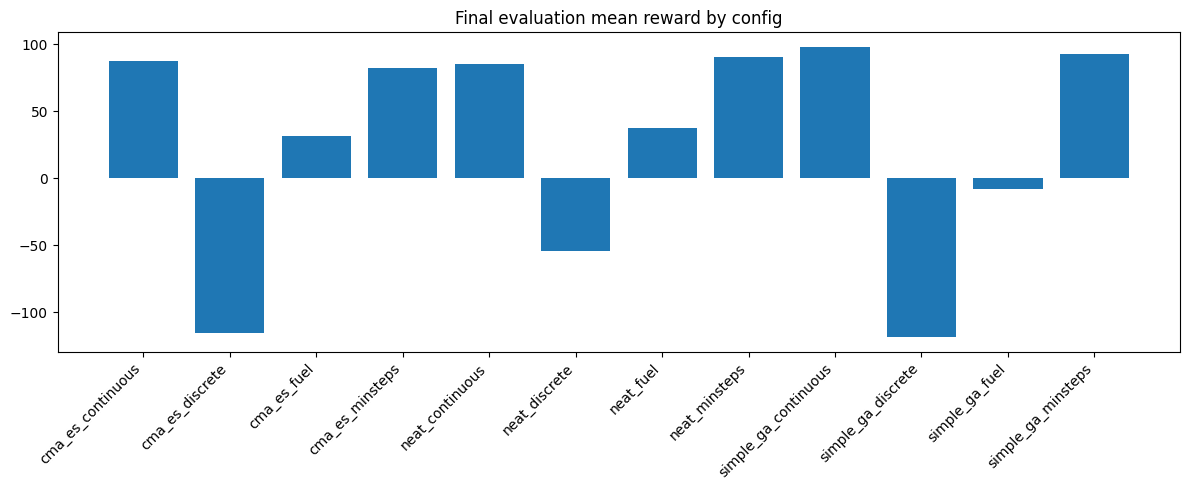

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\comparison_eval_mean_reward.png


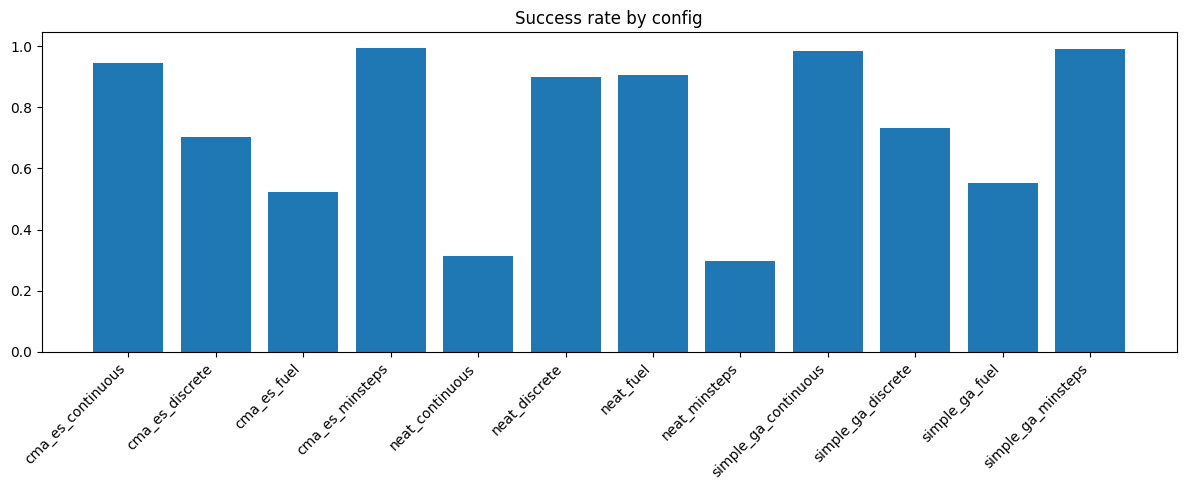

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\comparison_success_rate.png


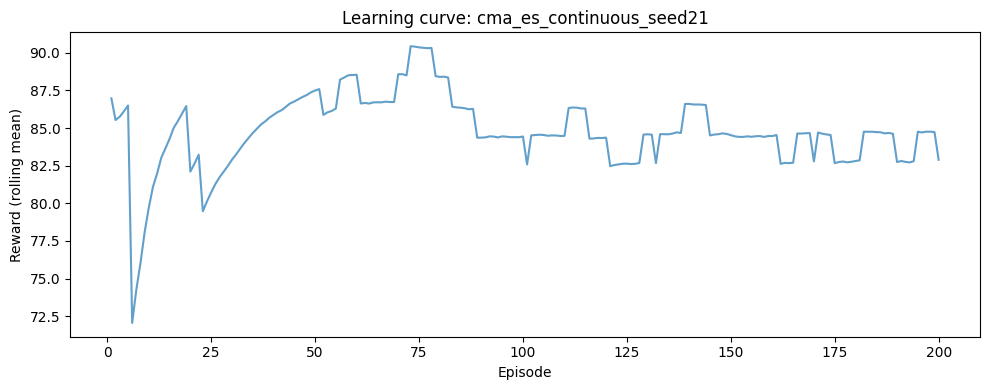

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_continuous_seed21_learning_curve.png


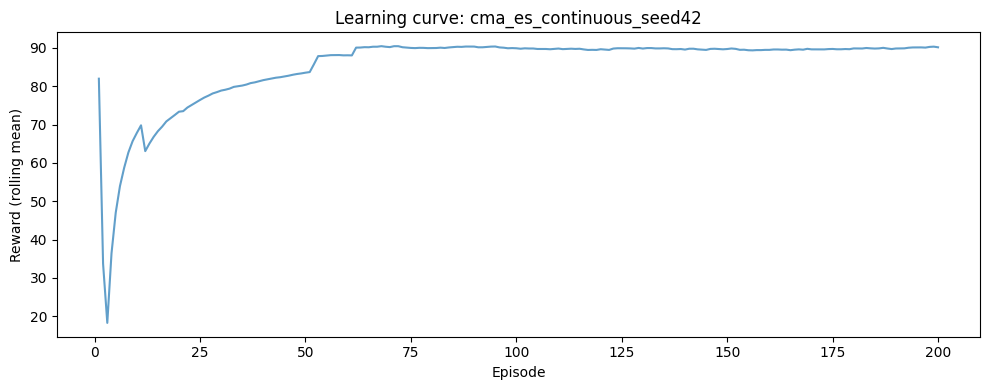

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_continuous_seed42_learning_curve.png


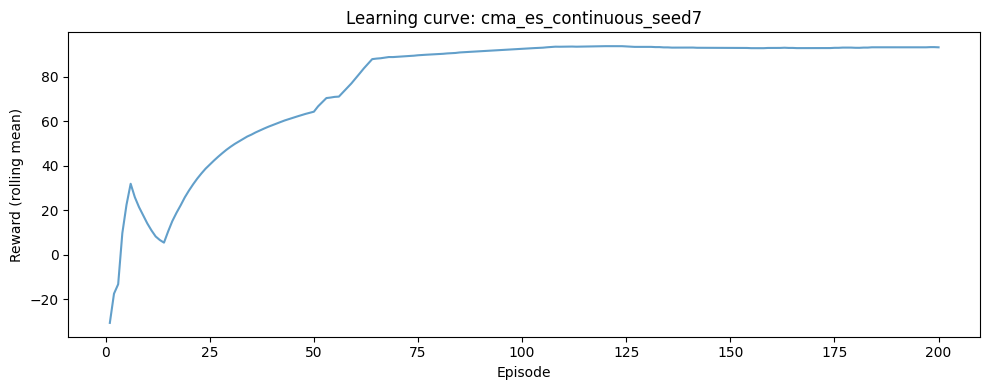

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_continuous_seed7_learning_curve.png


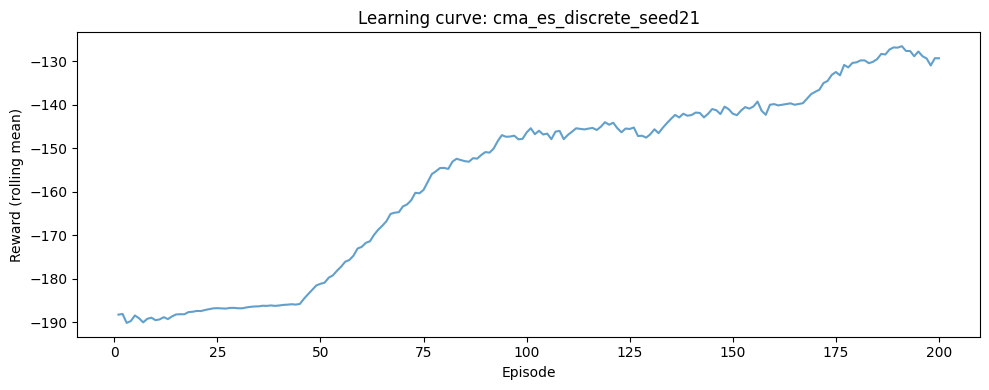

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_discrete_seed21_learning_curve.png


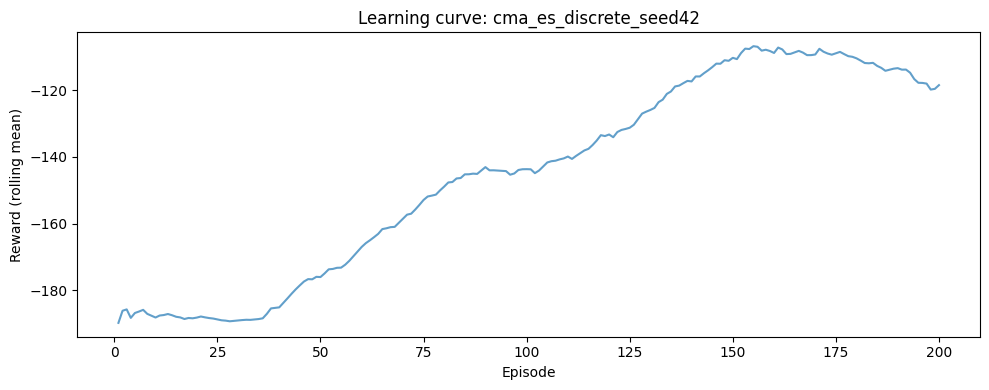

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_discrete_seed42_learning_curve.png


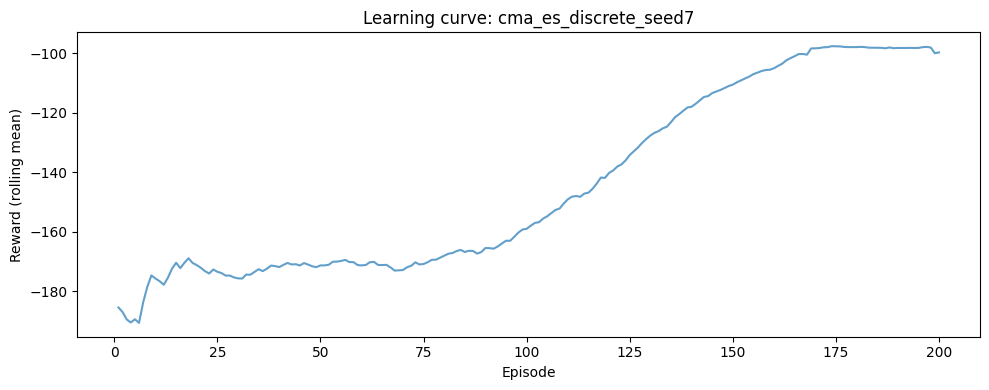

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_discrete_seed7_learning_curve.png


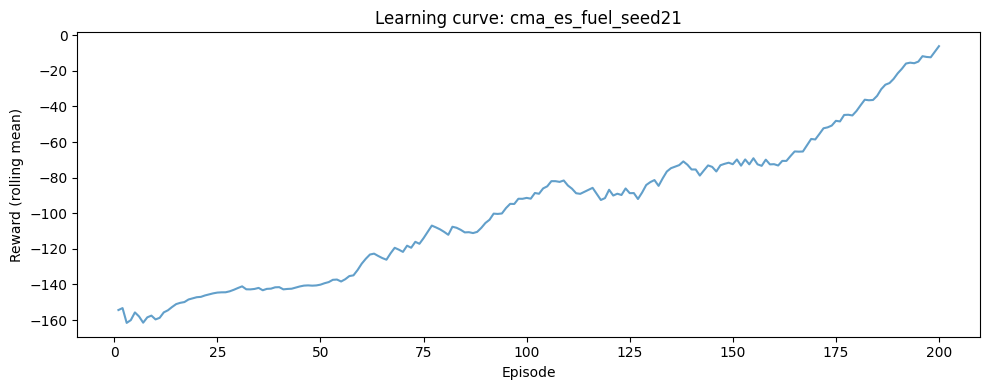

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_fuel_seed21_learning_curve.png


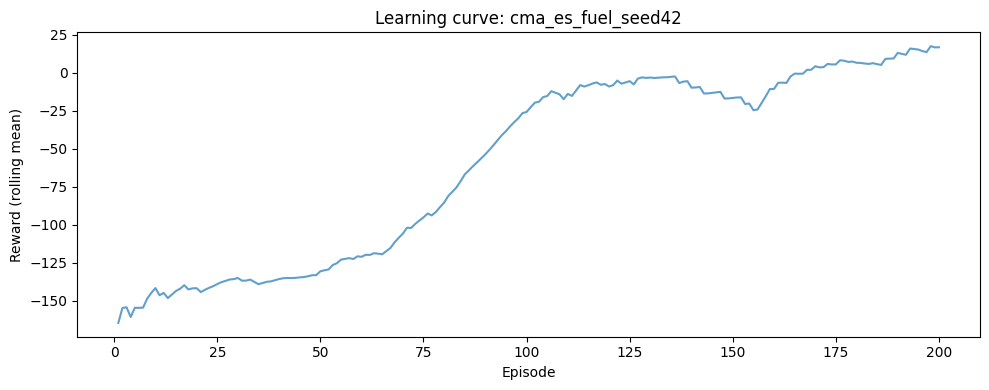

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_fuel_seed42_learning_curve.png


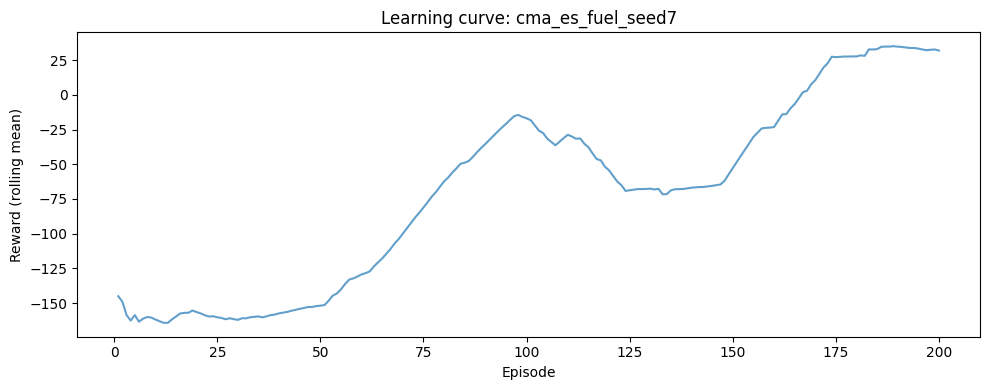

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_fuel_seed7_learning_curve.png


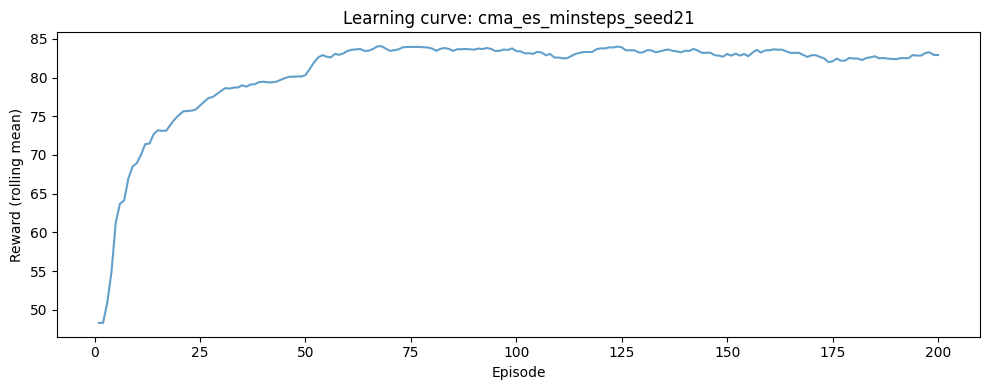

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_minsteps_seed21_learning_curve.png


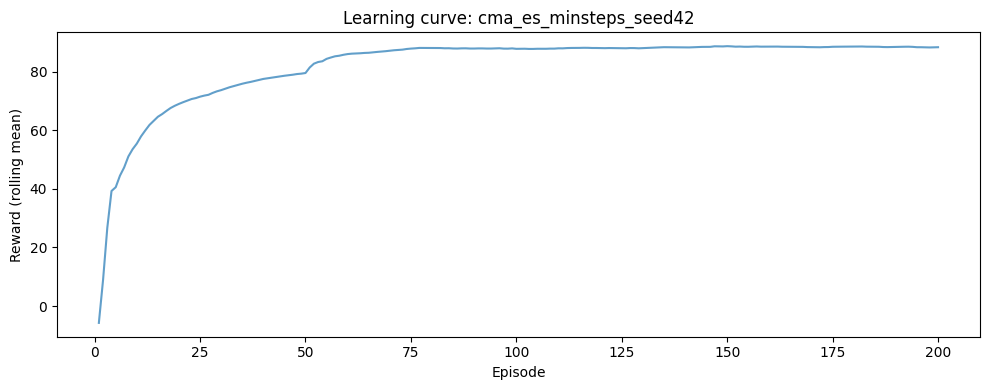

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_minsteps_seed42_learning_curve.png


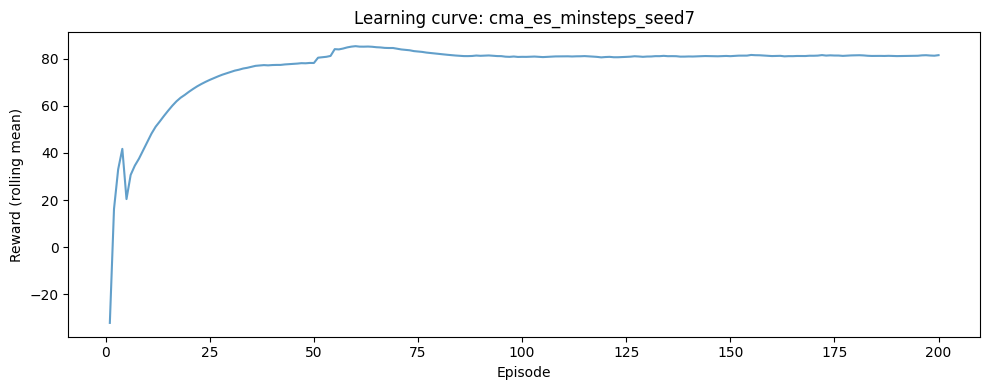

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\cma_es_minsteps_seed7_learning_curve.png


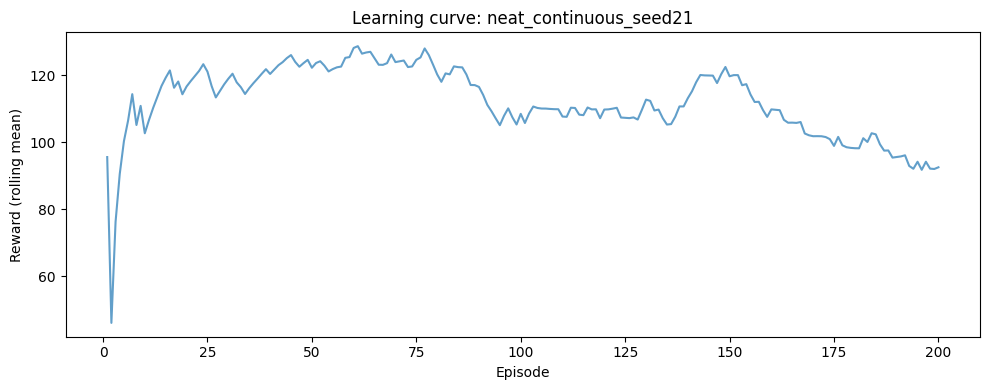

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_continuous_seed21_learning_curve.png


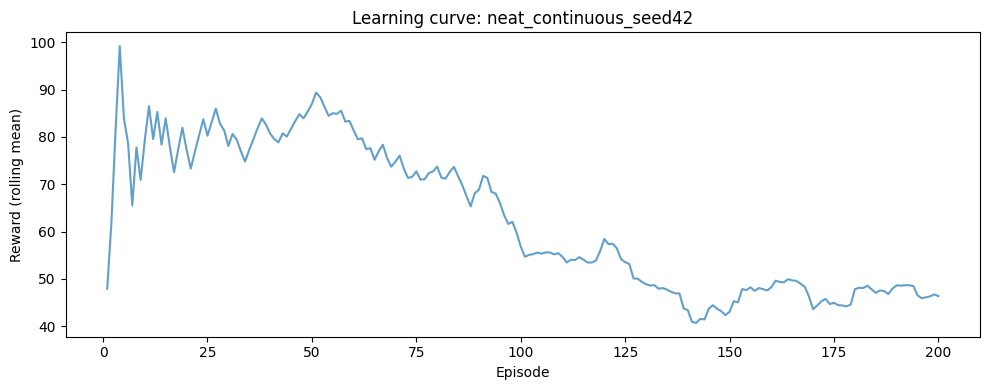

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_continuous_seed42_learning_curve.png


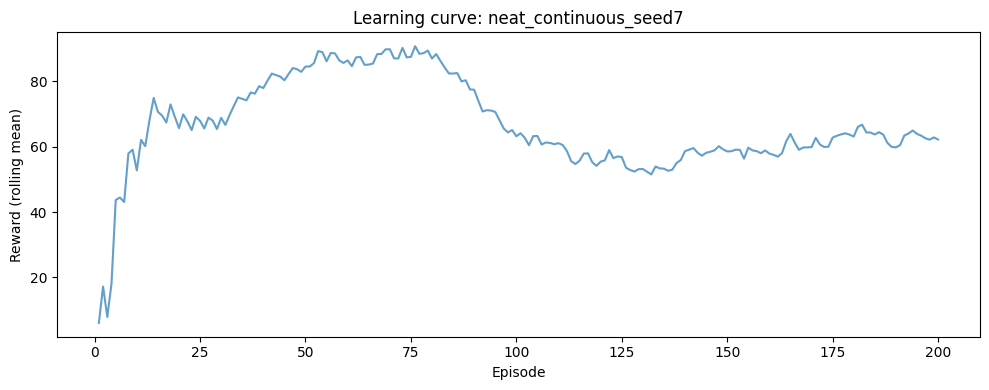

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_continuous_seed7_learning_curve.png


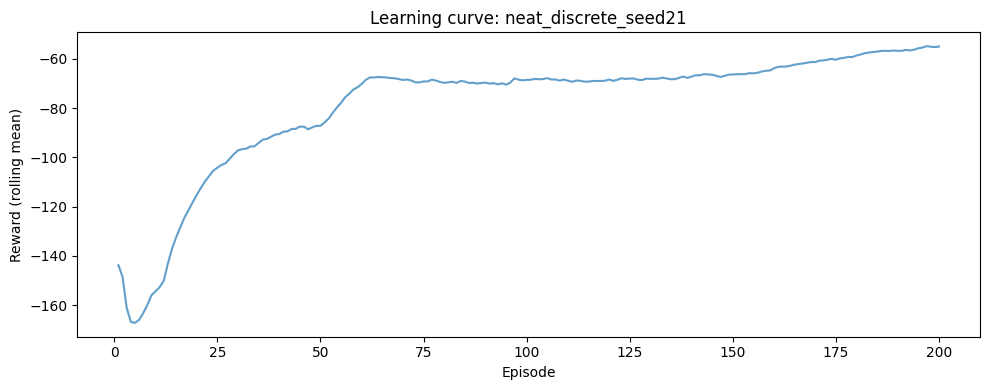

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_discrete_seed21_learning_curve.png


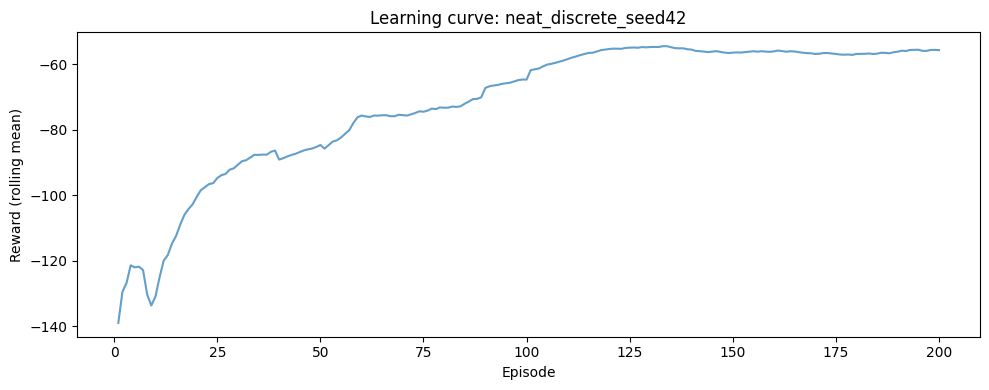

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_discrete_seed42_learning_curve.png


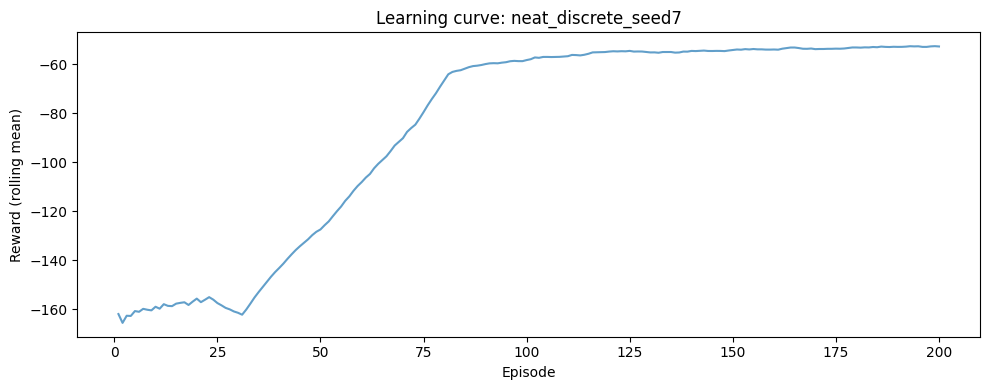

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_discrete_seed7_learning_curve.png


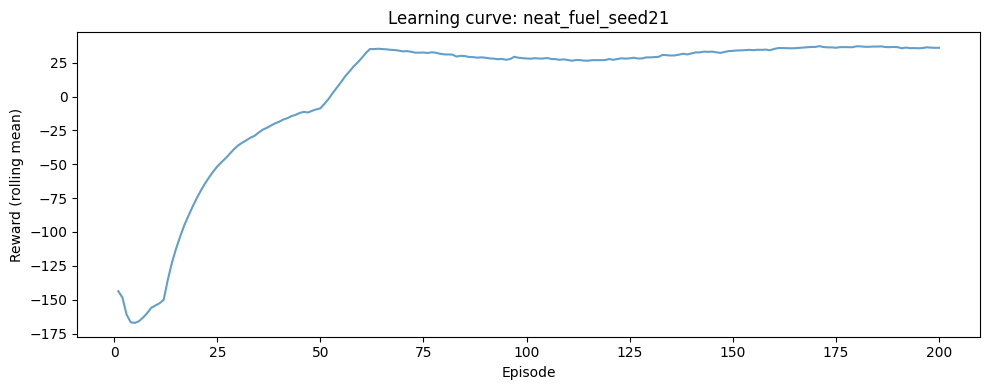

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_fuel_seed21_learning_curve.png


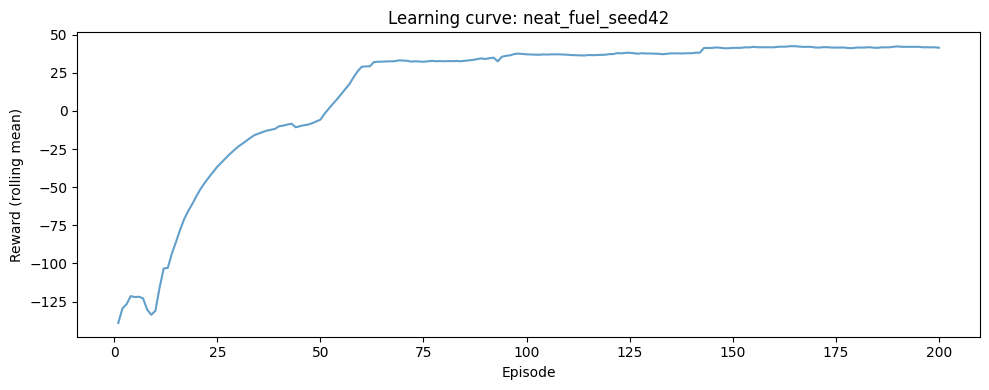

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_fuel_seed42_learning_curve.png


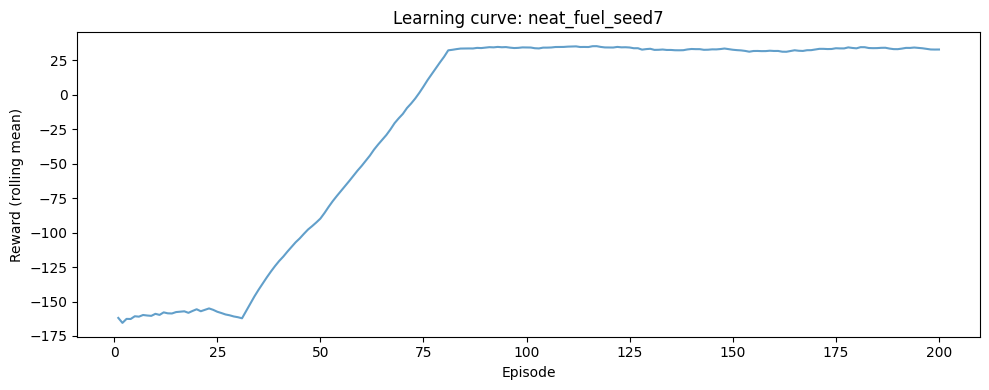

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_fuel_seed7_learning_curve.png


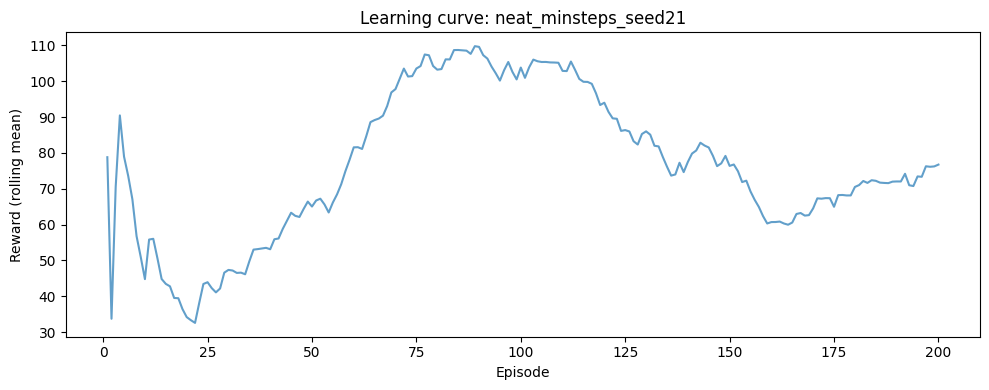

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_minsteps_seed21_learning_curve.png


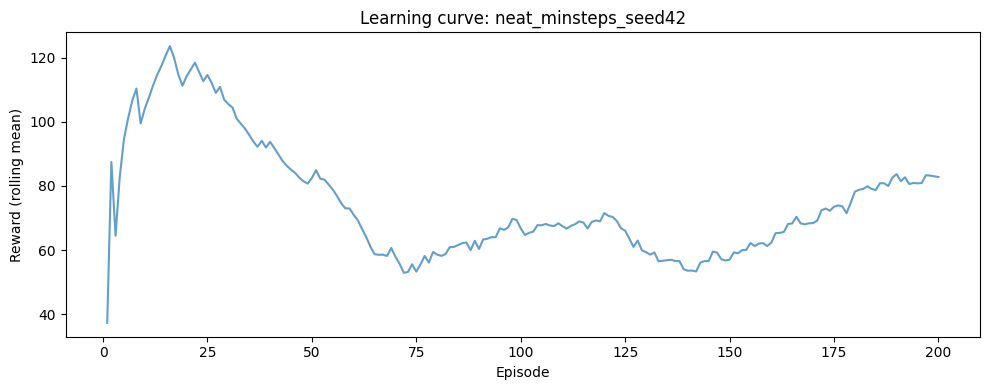

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_minsteps_seed42_learning_curve.png


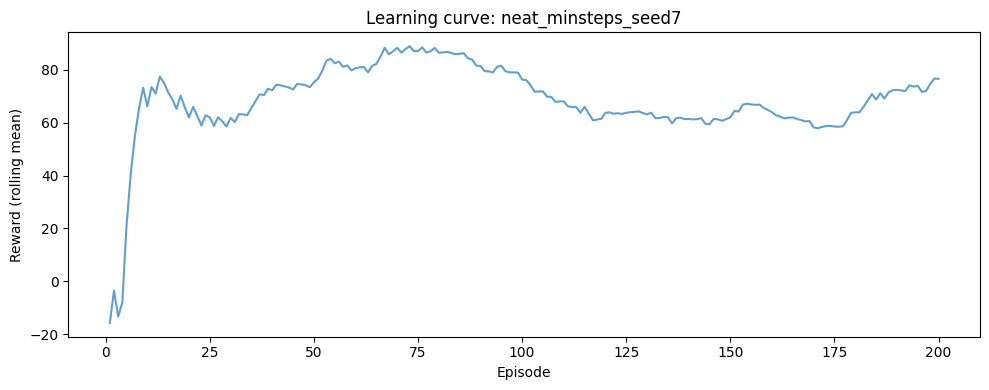

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\neat_minsteps_seed7_learning_curve.png


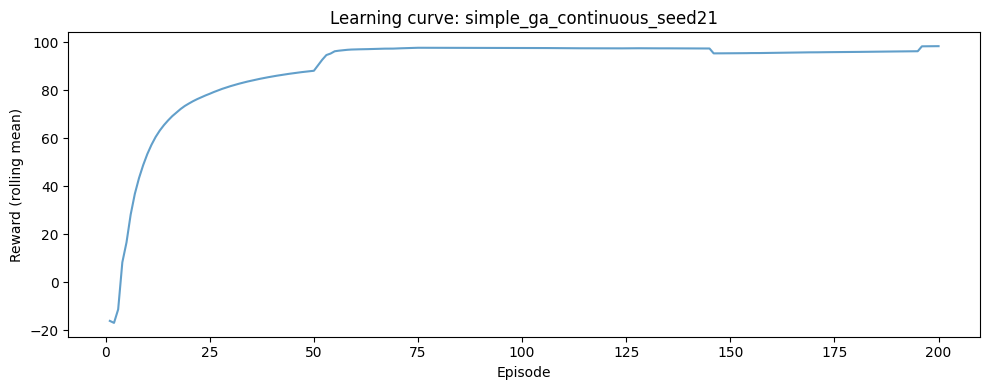

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_continuous_seed21_learning_curve.png


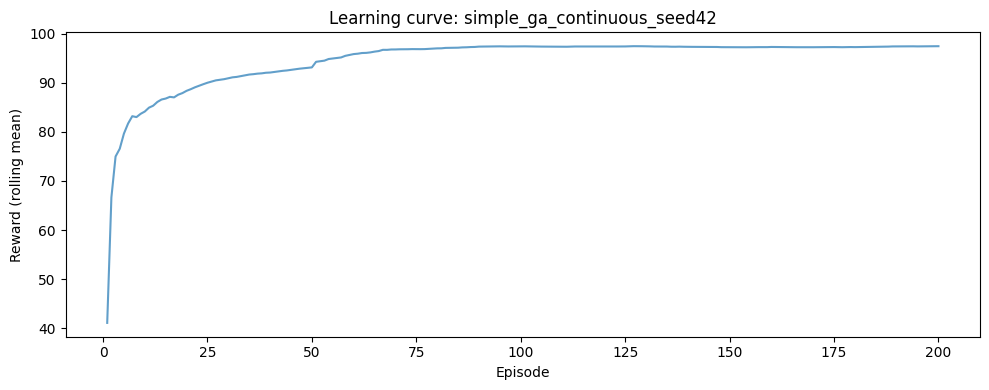

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_continuous_seed42_learning_curve.png


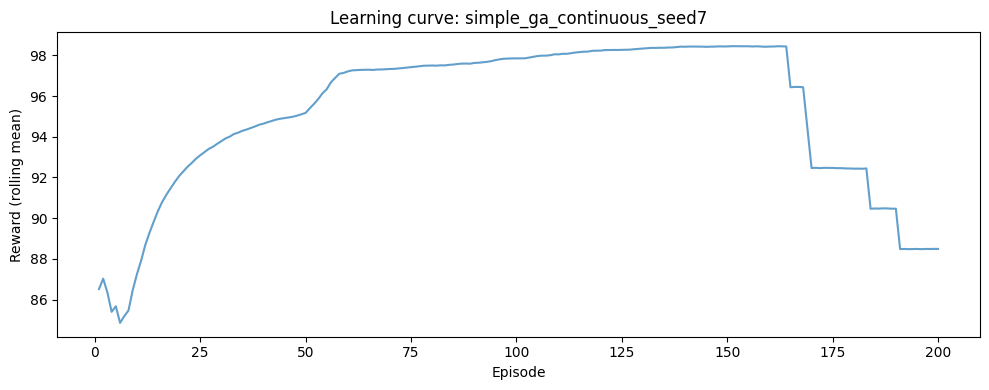

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_continuous_seed7_learning_curve.png


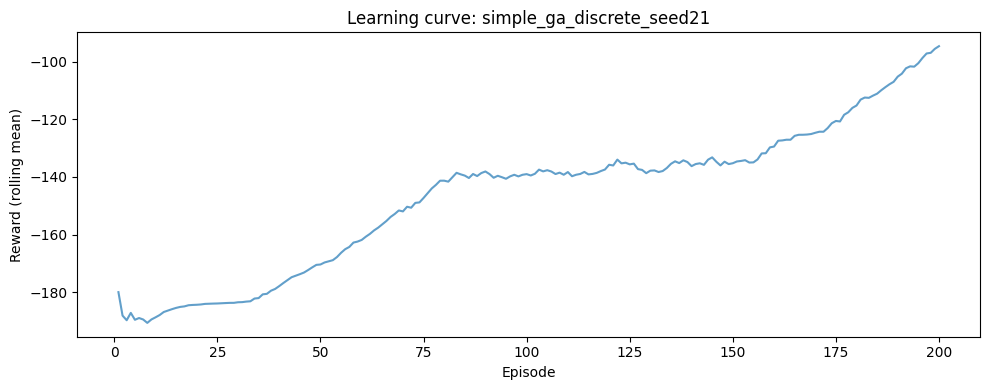

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_discrete_seed21_learning_curve.png


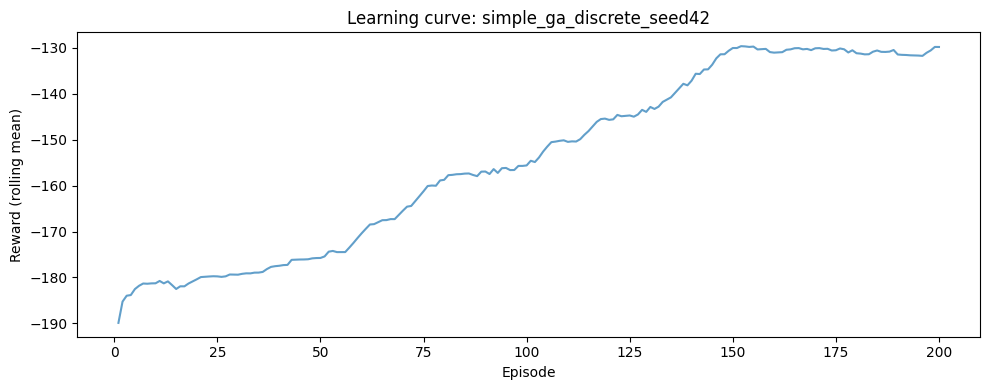

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_discrete_seed42_learning_curve.png


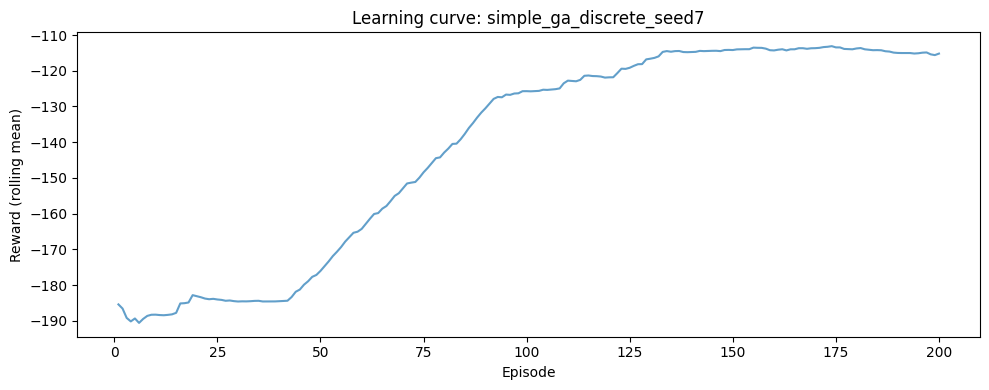

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_discrete_seed7_learning_curve.png


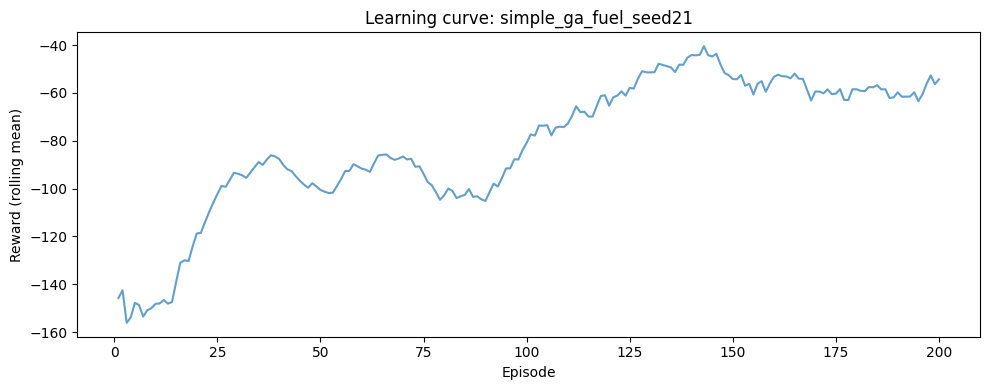

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_fuel_seed21_learning_curve.png


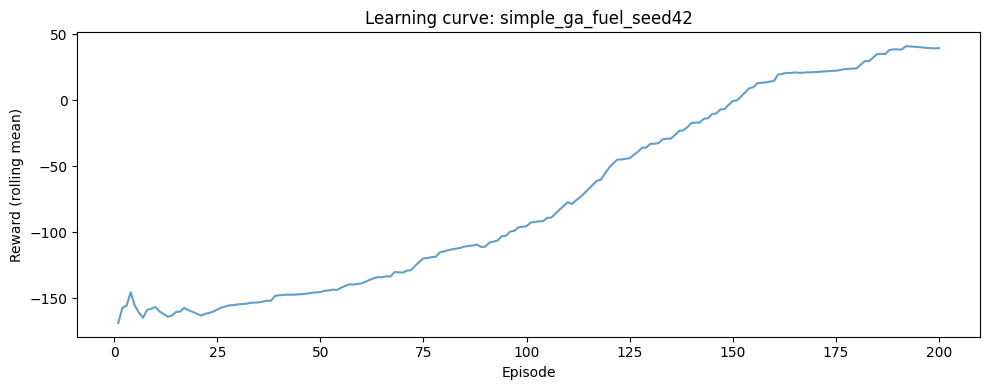

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_fuel_seed42_learning_curve.png


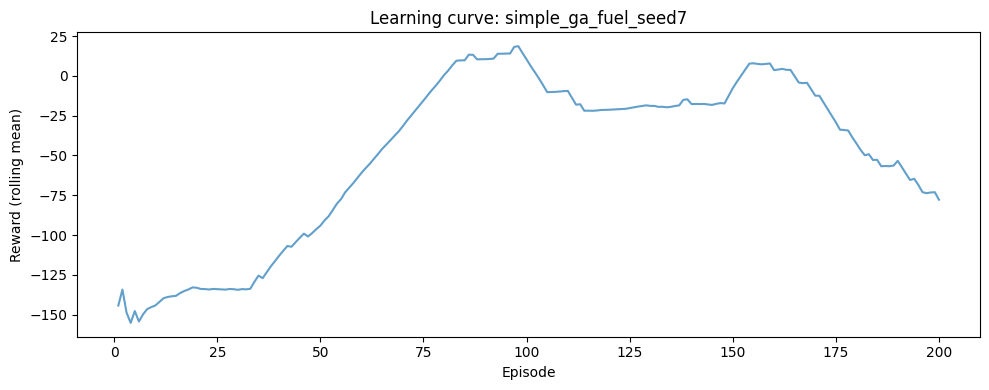

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_fuel_seed7_learning_curve.png


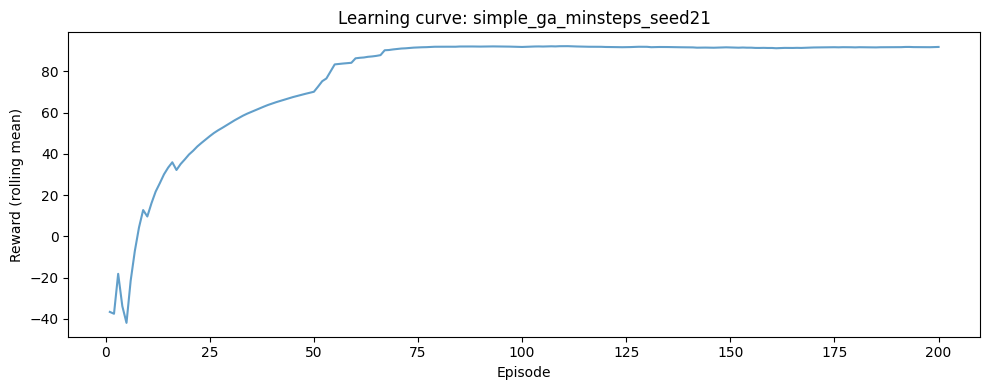

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_minsteps_seed21_learning_curve.png


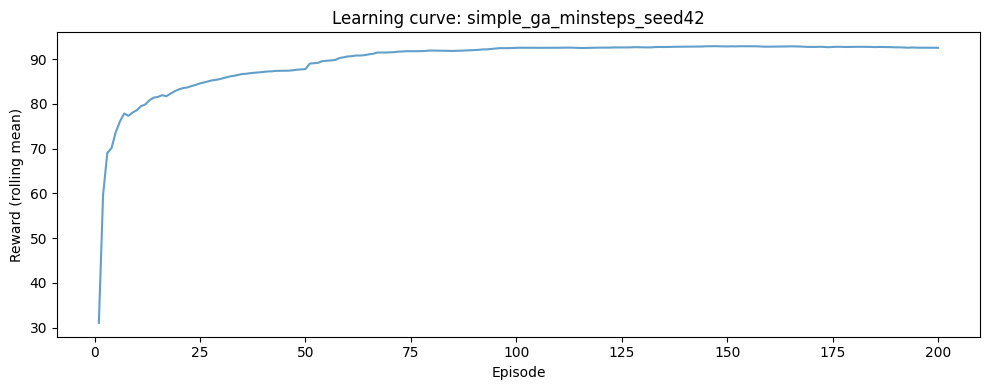

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_minsteps_seed42_learning_curve.png


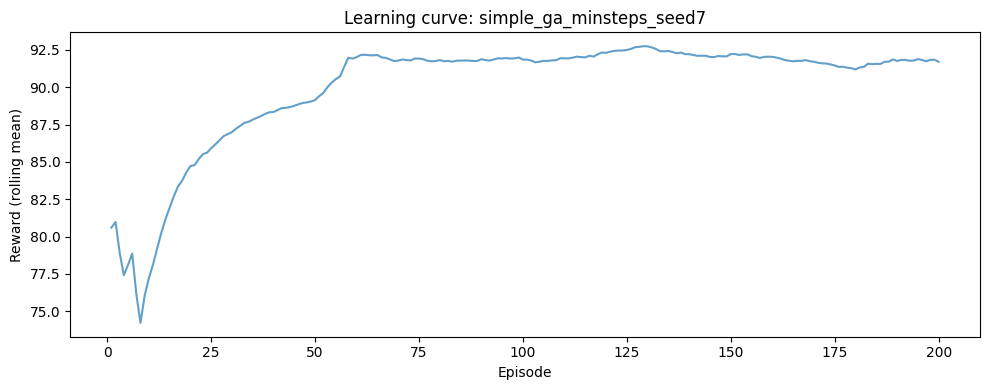

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\simple_ga_minsteps_seed7_learning_curve.png


In [57]:
# Plot results (per-model + comparison)
if results_df.empty:
    logs_dir = PROJECT_ROOT / 'outputs' / 'logs'
    results_df, episode_logs = load_results_from_logs(logs_dir)
    print(f'Loaded {len(results_df)} summaries and {len(episode_logs)} episode logs from {logs_dir}')

if results_df.empty:
    print('No results to plot yet.')
else:
    if SEABORN_AVAILABLE:
        sns.set_theme(style='whitegrid', context='talk')
    fig_dir = PROJECT_ROOT / 'outputs' / 'figures'
    fig_dir.mkdir(parents=True, exist_ok=True)

    # Comparison: mean eval reward and success rate by config
    summary_df = results_df.groupby('config_name', as_index=False).agg({
        'eval_mean_reward_last': 'mean',
        'success_rate': 'mean',
        'reward_mean': 'mean',
    })
    if 'eval_mean_reward_last' in summary_df.columns:
        plt.figure(figsize=(12, 5))
        if SEABORN_AVAILABLE:
            sns.barplot(data=summary_df, x='config_name', y='eval_mean_reward_last')
        else:
            plt.bar(summary_df['config_name'], summary_df['eval_mean_reward_last'])
        plt.xticks(rotation=45, ha='right')
        plt.title('Final evaluation mean reward by config')
        plt.tight_layout()
        out_path = fig_dir / 'comparison_eval_mean_reward.png'
        plt.savefig(out_path, dpi=180)
        plt.show()
        print('Saved:', out_path)

    if 'success_rate' in summary_df.columns:
        plt.figure(figsize=(12, 5))
        if SEABORN_AVAILABLE:
            sns.barplot(data=summary_df, x='config_name', y='success_rate')
        else:
            plt.bar(summary_df['config_name'], summary_df['success_rate'])
        plt.xticks(rotation=45, ha='right')
        plt.title('Success rate by config')
        plt.tight_layout()
        out_path = fig_dir / 'comparison_success_rate.png'
        plt.savefig(out_path, dpi=180)
        plt.show()
        print('Saved:', out_path)

    # Per-model learning curves
    if episode_logs:
        grouped = {}
        for cfg_name, seed, df in episode_logs:
            grouped.setdefault(cfg_name, []).append(df)
        for cfg_name, dfs in grouped.items():
            plt.figure(figsize=(10, 4))
            for df in dfs:
                if 'episode' in df.columns and 'reward' in df.columns:
                    y = df['reward'].rolling(window=50, min_periods=1).mean()
                    plt.plot(df['episode'], y, alpha=0.7)
            plt.xlabel('Episode')
            plt.ylabel('Reward (rolling mean)')
            plt.title(f'Learning curve: {cfg_name}')
            plt.tight_layout()
            out_path = fig_dir / f"{cfg_name}_learning_curve.png"
            plt.savefig(out_path, dpi=180)
            plt.show()
            print('Saved:', out_path)
    else:
        print('No per-episode logs found for learning curves.')

## Cross-agent comparison plots

The charts below are the notebook version of the GA-style comparison figures. They compare models inside each family so you can see the same kind of plot for discrete, fuel, minsteps, and continuous runs.

These plots are generated inline with `plt.show()`, so the output stays visible directly in this notebook while the figures are also saved under `outputs/figures`.


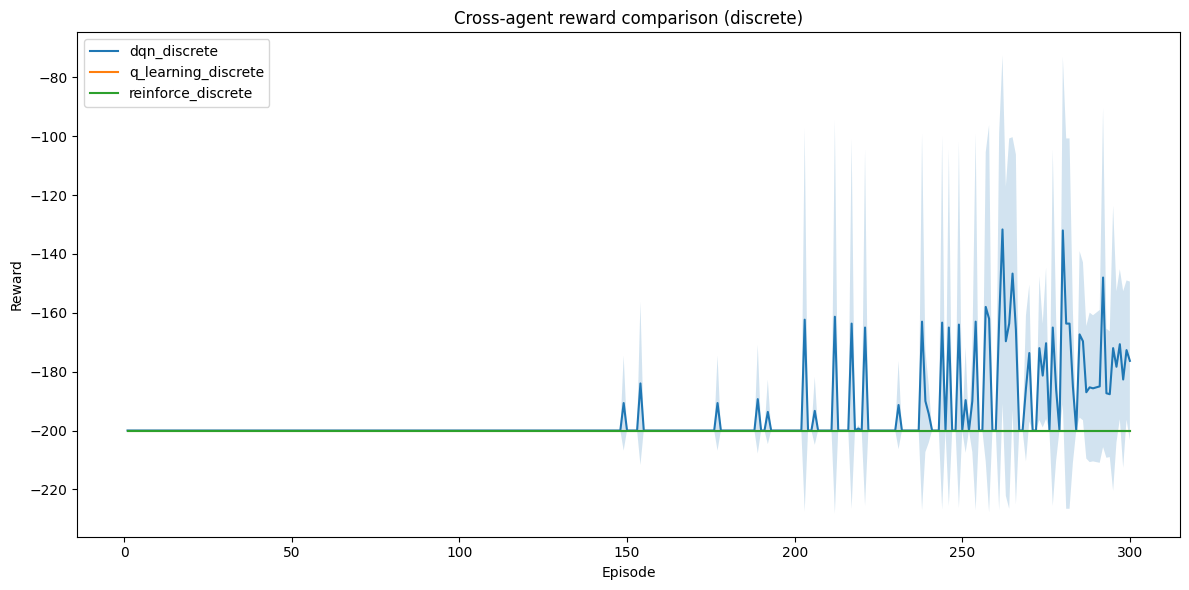

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\discrete_cross_agent_reward.png
No configs found for continuous.
No configs found for fuel.
No configs found for minsteps.


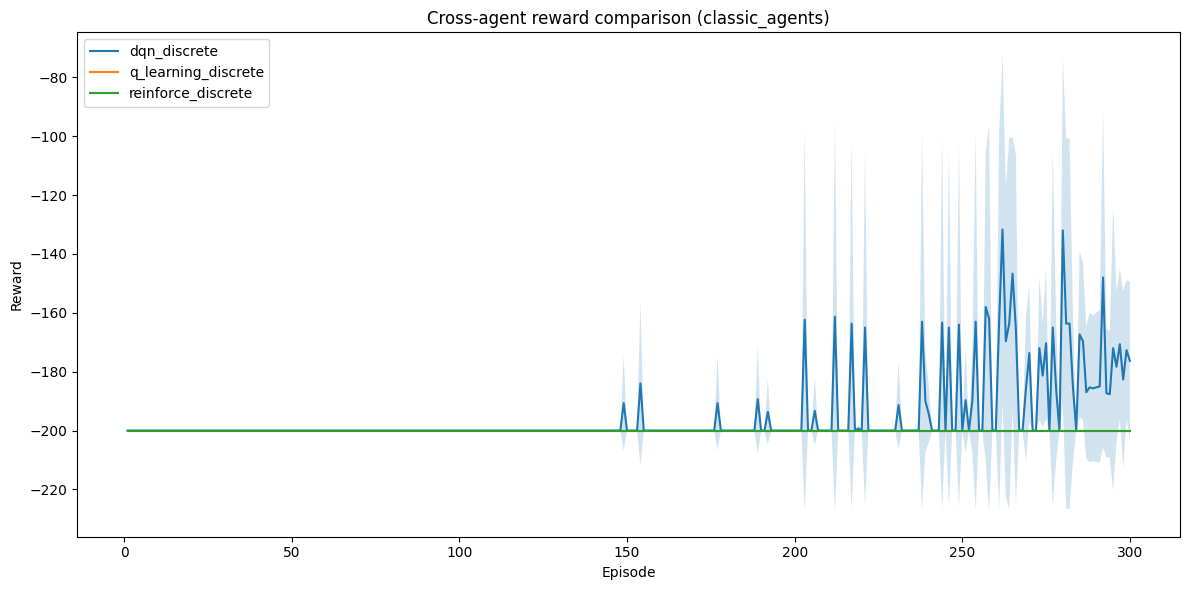

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\classic_agents_cross_agent_reward.png


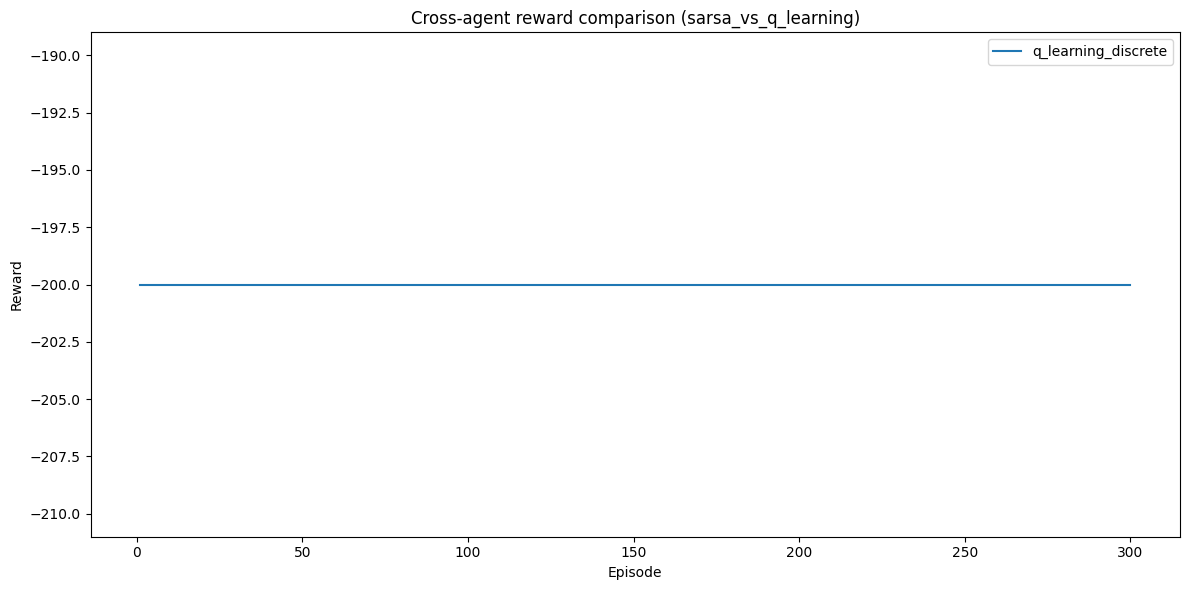

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\sarsa_vs_q_learning_cross_agent_reward.png


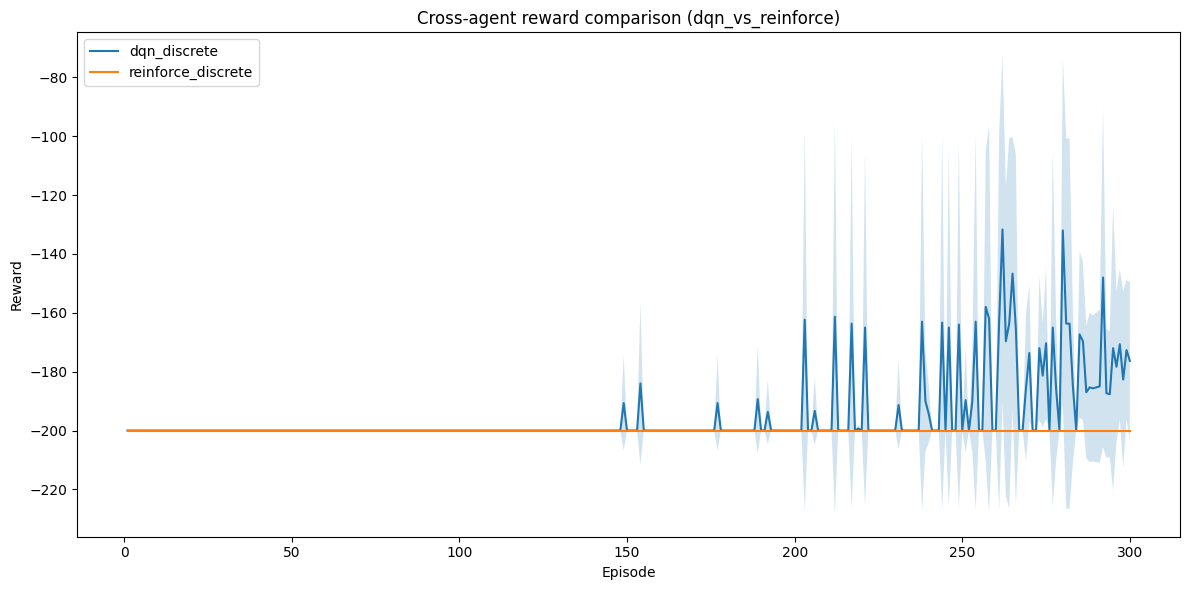

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\dqn_vs_reinforce_cross_agent_reward.png


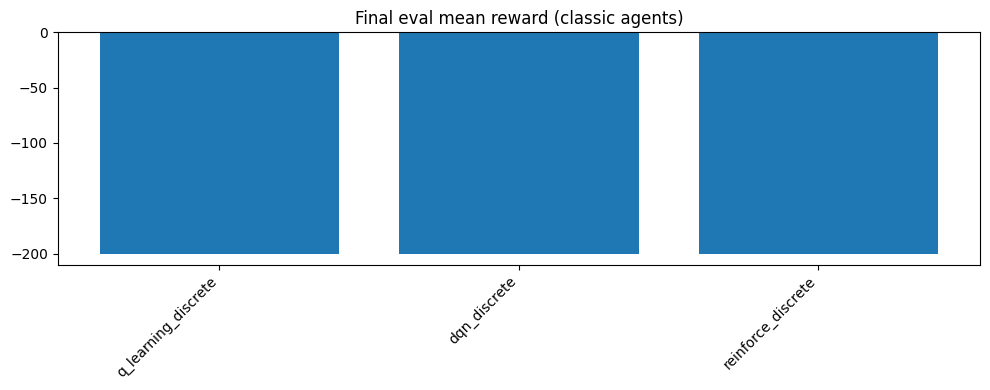

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\classic_agents_eval_mean_reward.png


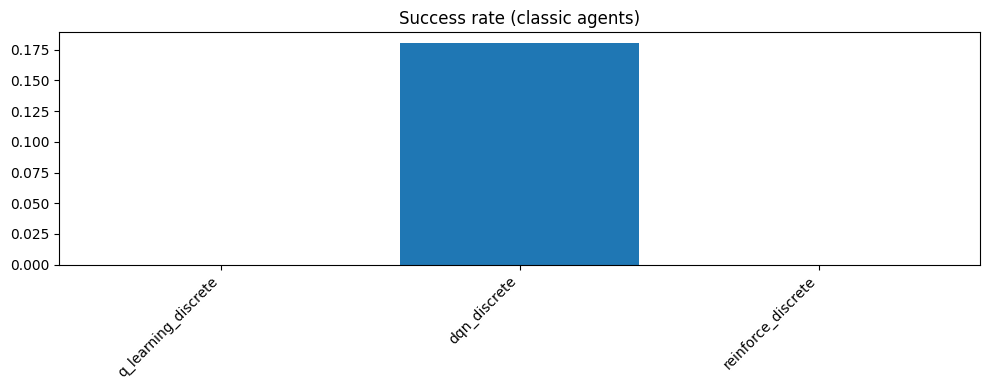

Saved: C:\Users\jmlar\OneDrive\Documentos\GitHub\mountain-pendulum\outputs\figures\classic_agents_success_rate.png


In [62]:
# Cross-agent comparison plots (family + selected agents)
import numpy as np
import pandas as pd
import re

if results_df.empty:
    logs_dir = PROJECT_ROOT / "outputs" / "logs"
    results_df, episode_logs = load_results_from_logs(logs_dir)
    print(f"Loaded {len(results_df)} summaries and {len(episode_logs)} episode logs from {logs_dir}")

fig_dir = PROJECT_ROOT / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

def _normalize_name(name: str) -> str:
    return re.sub(r"_seed\d+$", "", name)

def _aggregate_episode_curves(dfs):
    combined = pd.concat(dfs, ignore_index=True)
    if not {"episode", "reward"}.issubset(combined.columns):
        return None
    grouped = combined.groupby("episode")["reward"]
    mean = grouped.mean()
    std = grouped.std().fillna(0.0)
    return mean.index.to_numpy(), mean.to_numpy(), std.to_numpy()

def _plot_family(family_name, base_names):
    if not base_names:
        print(f"No configs found for {family_name}.")
        return
    plt.figure(figsize=(12, 6))
    for base in base_names:
        dfs = [df for name, _, df in episode_logs if _normalize_name(name) == base]
        if not dfs:
            continue
        agg = _aggregate_episode_curves(dfs)
        if not agg:
            continue
        x, y_mean, y_std = agg
        plt.plot(x, y_mean, label=base)
        if np.any(y_std > 0):
            plt.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title(f"Cross-agent reward comparison ({family_name})")
    plt.legend(loc="best")
    plt.tight_layout()
    out_path = fig_dir / f"{family_name}_cross_agent_reward.png"
    plt.savefig(out_path, dpi=180)
    plt.show()
    print("Saved:", out_path)

available_base = sorted({_normalize_name(name) for name, _, _ in episode_logs})
family_keywords = {
    "discrete": ["discrete"],
    "continuous": ["continuous"],
    "fuel": ["fuel"],
    "minsteps": ["minsteps"],
}

for family_name, keywords in family_keywords.items():
    matched = [c for c in available_base if any(k in c for k in keywords)]
    _plot_family(family_name, matched)

# Targeted comparison: classic discrete agents
classic_keywords = ["sarsa", "q_learning", "dqn", "reinforce"]
classic_configs = [c for c in available_base if any(k in c for k in classic_keywords)]
_plot_family("classic_agents", classic_configs)

# Pairwise classic comparisons
sarsa_q_configs = [c for c in classic_configs if ("sarsa" in c or "q_learning" in c)]
_plot_family("sarsa_vs_q_learning", sarsa_q_configs)
dqn_reinforce_configs = [c for c in classic_configs if ("dqn" in c or "reinforce" in c)]
_plot_family("dqn_vs_reinforce", dqn_reinforce_configs)

if not results_df.empty:
    results_df = results_df.copy()
    results_df["config_name_base"] = results_df["config_name"].apply(_normalize_name)
    classic_summary = results_df[results_df["config_name_base"].isin(classic_configs)]
    if not classic_summary.empty:
        if "eval_mean_reward_last" in classic_summary.columns:
            plt.figure(figsize=(10, 4))
            if SEABORN_AVAILABLE:
                sns.barplot(data=classic_summary, x="config_name_base", y="eval_mean_reward_last")
            else:
                plt.bar(classic_summary["config_name_base"], classic_summary["eval_mean_reward_last"])
            plt.xticks(rotation=45, ha="right")
            plt.title("Final eval mean reward (classic agents)")
            plt.tight_layout()
            out_path = fig_dir / "classic_agents_eval_mean_reward.png"
            plt.savefig(out_path, dpi=180)
            plt.show()
            print("Saved:", out_path)

        if "success_rate" in classic_summary.columns:
            plt.figure(figsize=(10, 4))
            if SEABORN_AVAILABLE:
                sns.barplot(data=classic_summary, x="config_name_base", y="success_rate")
            else:
                plt.bar(classic_summary["config_name_base"], classic_summary["success_rate"])
            plt.xticks(rotation=45, ha="right")
            plt.title("Success rate (classic agents)")
            plt.tight_layout()
            out_path = fig_dir / "classic_agents_success_rate.png"
            plt.savefig(out_path, dpi=180)
            plt.show()
            print("Saved:", out_path)
    else:
        print("No classic agent summaries found for bar charts.")

In [59]:
print("results_df rows:", len(results_df))
print("episode_logs rows:", len(episode_logs))
print("available configs:", sorted({name for name, _, _ in episode_logs})[:20])

results_df rows: 36
episode_logs rows: 36
available configs: ['cma_es_continuous_seed21', 'cma_es_continuous_seed42', 'cma_es_continuous_seed7', 'cma_es_discrete_seed21', 'cma_es_discrete_seed42', 'cma_es_discrete_seed7', 'cma_es_fuel_seed21', 'cma_es_fuel_seed42', 'cma_es_fuel_seed7', 'cma_es_minsteps_seed21', 'cma_es_minsteps_seed42', 'cma_es_minsteps_seed7', 'neat_continuous_seed21', 'neat_continuous_seed42', 'neat_continuous_seed7', 'neat_discrete_seed21', 'neat_discrete_seed42', 'neat_discrete_seed7', 'neat_fuel_seed21', 'neat_fuel_seed42']


## Tips

- Set `RUN_FAST = False` for full-length training.
- Use `SELECT_CONFIGS` or `SELECT_AGENTS` to limit runs.
- If a model is skipped, install its dependency (stable-baselines3, torch, neat-python, cma).